# BT4221 validate_cleaning_agent Notebook

## Local Resources (Windows)

### Setup spark
**Only if using local runtime!!**

In [1]:
# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Initialise findspark
# import findspark
# findspark.init()

# # Install Langgraph
# !pip install -U langgraph langchain langchain-openai

# # # Set java version
# # import os
# # java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# # os.environ['JAVA_HOME'] = java_path

## Import Libraries

In [2]:
import json
import os
from getpass import getpass
from typing import TypedDict, Optional, Literal, Any, Dict, List
from pydantic import BaseModel, Field
from openai import OpenAI
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.functions import (
    col, year, month, dayofweek, hour, when,
    unix_timestamp, skewness, kurtosis,
    percentile_approx, count, isnan
)
from pyspark.storagelevel import StorageLevel
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
import string
import time


## Create Spark Session

### Google Colab Spark Session Config

In [3]:
# if "spark" in locals():
#     spark.stop()
#     print("Existing Spark session stopped.")

# spark = SparkSession.builder \
#     .appName("BT4221") \
#     .master("local[2]") \
#     .config("spark.driver.memory", "8g") \
#     .config("spark.driver.maxResultSize", "4g") \
#     .config("spark.sql.shuffle.partitions", "50") \
#     .config("spark.memory.fraction", "0.8") \
#     .config("spark.memory.storageFraction", "0.3") \
#     .getOrCreate()

# # Verify SparkSession created successfully
# print("App:", spark.sparkContext.appName)

### Optimised Spark Sessions Config

In [4]:
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

# Force local networking to avoid driver/executor block transfer issues
# such as connect(..) failed with "Can't assign requested address".
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

# Stable local Spark session
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("US_Accidents")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.port", "4050")
    .config("spark.blockManager.port", "4051")
    .config("spark.port.maxRetries", "50")
    .config("spark.local.dir", "/tmp/spark-local")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "24")
    .config("spark.default.parallelism", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.network.timeout", "300s")
    .config("spark.executor.heartbeatInterval", "30s")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)
print("Driver host:", spark.conf.get("spark.driver.host"))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/13 01:31:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/13 01:31:14 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
26/04/13 01:31:14 WARN Utils: Service 'sparkDriver' could not bind on port 4050. Attempting port 4051.
26/04/13 01:31:14 WARN Utils: Service 'sparkDriver' could not bind on port 4051. Attempting port 4052.
26/04/13 01:31:14 WARN Utils: Service 'sparkDriver' could not bind on port 4052. Attempting port 4053.
26/04/13 01:31:14 WARN Utils: Service 'sparkDriver' could not bind on port 4053. Attempting port 4054.
26/04/13 01:31:14 WARN Utils: Service 'Spar

App: US_Accidents
Master: local[2]
Driver host: 127.0.0.1


### Load Dataset

In [5]:
# # Upload CSV
# df = spark.read.csv("US_Accidents_March23.csv", header=True, inferSchema=True)

# Default parquet path from current working directory
parquet_path = "cleaned_parquet"

# Optional absolute paths
# parquet_path = "C:/Users/Kayle/OneDrive/Desktop/BT/BT4221/spark_proj/cleaned_parquet"
# parquet_path = "C:/Users/iiank/OneDrive/Documents/NUS/Y2/Y2S2/BT4221/BT4221 Project/cleaned_parquet"

df = spark.read.parquet(parquet_path)
df.show(5)

26/04/13 01:31:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+----------------+--------+-------------------+-------------------+------------------+------------------+-------------------+-----------------+----------+------+-----+----------+----------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+-----+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+
|Airport_Code|Start_Time_Month|Severity|         Start_Time|           End_Time|         Start_Lat|         Start_Lng|       Distance(mi)|           Street|      City|County|State|   Zipcode|  Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Crossing|Junction| Stop|Traffic_Signal|Sunrise_Sunset|Civil_Twil

## Skill.md

### Skill: validate-cleaning

In [6]:
SKILL_PROFILE = """
---
name: validate-cleaning
description: >
  Comprehensively profile a PySpark DataFrame to surface data quality issues.
  Produces a structured JSON-like profile used by the downstream feature engineering
  agent to automate imputation, filtering, and feature selection.
mode: organisational
inputs:
  - df: PySpark DataFrame
  - target_col: Name of the target variable
  - timestamp_cols: List of columns to treat as timestamps
outputs:
  - profile: Nested dictionary of all data characteristics and recommendations
---

# Dataset Profiling Skill

## Purpose
This skill is the FIRST node in the data pipeline. It performs a thorough
examination of the input DataFrame and produces a profile dictionary.
This profile is the input to the downstream feature engineering agent.

## Key Metrics & Logic
- **Structural:** Total rows, columns, column names, and data types.
- **Missingness:** Categorizes null density from "none" to "critical."
- **Numerical:** Uses IQR for outlier detection and Skewness for imputation strategy (Mean vs Median).
- **Categorical:** Flags high cardinality and "Near-Zero Variance" (top category > 95%).
- **Temporal:** Detects "Sparse Years" (years with < 1% of total data) to identify reporting shifts.
- **Correlation:** Computes Pearson correlation to identify redundant features (Threshold > 0.9).

## Output Format
Return a single Python dictionary with this exact structure:
```python
profile = {
    "structural_overview": {
        "total_rows": int,
        "total_columns": int,
        "column_types": {
            "col_name": "numerical/categorical/timestamp/time_derived/boolean"
        }
    },
    "missing_values": {
        "col_name": {
            "null_count": int,
            "null_pct": float,
            "severity": "none/low/moderate/high/critical",
            "recommendation": str
        }
    },
    "numerical_analysis": {
        "col_name": {
            "mean": float,
            "std": float,
            "min": float,
            "max": float,
            "skewness": float,
            "kurtosis": float,
            "outlier_count": int,
            "distribution": "normal/moderate_skew/high_skew",
            "imputation_recommendation": "mean/median"
        }
    },
    "categorical_analysis": {
        "col_name": {
            "distinct_count": int,
            "top_5_values": {str: int},
            "bottom_5_values": {str: int},
            "near_zero_variance": bool,
            "encoding_recommendation": str
        }
    },
    "timestamp_analysis": {
        "col_name": {
            "min": str,
            "max": str,
            "yearly_distribution": {str: int},
            "sparse_years": [int],
            "temporal_consistency": "consistent/inconsistent"
        }
    },
    "target_analysis": {
        "column": str,
        "class_distribution": {str: int},
        "imbalance_ratio": float,
        "imbalance_classification": str,
        "smote_recommendation": str
    },
    "correlation_analysis": {
        "highly_correlated_pairs": [
            {
                "col1": str,
                "col2": str,
                "correlation": float,
                "recommendation": str
            }
        ],
        "near_duplicate_pairs": [
            {
                "col1": str,
                "col2": str,
                "correlation": float,
                "recommendation": str
            }
        ]
    },
    "quality_summary": {
        "total_issues": int,
        "critical_issues": [str],
        "warnings": [str],
        "overall_quality_score": "good/moderate/poor"
    }
}
```

## Important Notes
- This skill is PURE PYTHON AND PYSPARK — no LLM is involved
- All computations must be done using PySpark functions
- Cache the DataFrame before profiling to avoid recomputation:
  df.cache()
- The output profile is stored in AgentState["profile"]
- The downstream cleaning agent reads AgentState["profile"]
  and uses it as its SOLE INPUT for making cleaning decisions
- Do not hardcode any column names — profile ALL columns
  dynamically based on schema
- Log progress as each section completes so the user can
  track profiling progress on large datasets
"""

import os
os.makedirs("skills/profile-dataset", exist_ok=True)
with open("skills/profile-dataset/SKILL.md", "w") as f:
    f.write(SKILL_PROFILE.strip())
print("Written: skills/profile-dataset/SKILL.md")

Written: skills/profile-dataset/SKILL.md


## Previous Agent Skill (Pyspark)

### Basic Dataset Exploration

In [7]:
# rows = df.count()
# cols = len(df.columns)

# print("Number of rows:", rows)
# print("Number of columns:", cols)

In [8]:
# from pyspark.sql.types import IntegerType, DoubleType, FloatType, StringType, BooleanType, TimestampType

# numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType, FloatType))]
# categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
# boolean_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, BooleanType)]
# timestamp_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, TimestampType)]

# print(f"Numeric columns: ({len(numeric_cols)}) {numeric_cols}")
# print(f"Categorical columns: ({len(categorical_cols)}) categorical_cols")
# print(f"Boolean columns: ({len(boolean_cols)}) boolean_cols")
# print(f"Timestamp columns: ({len(timestamp_cols)}) timestamp_cols")
# print(f"Total number of columns: {len(numeric_cols) + len(categorical_cols) + len(boolean_cols) + len(timestamp_cols)}")

In [9]:
# df.describe().show()

### Previous Pyspark Function

**This is the previous 1 function = 1 skill from work_v1.ipynb.  
The updated form of this function is below, under "Agent Skill with Helper Functions".**

In [10]:
# def validate_cleaning(df, target_col,
#                     timestamp_cols=None):
#     """
#     Profiles a PySpark DataFrame.
#     Produces a structured dictionary consumed by the downstream feature engineering agent.
#     """

#     # Read skill file (shows marker skill is being followed)
#     with open("skills/profile-dataset/SKILL.md", "r") as f:
#         print(">> Following skill: profile-dataset/SKILL.md")

#     timestamp_cols = timestamp_cols or []
#     profile = {}

#     # Cache df to avoid recomputation
#     df.cache()
#     total_rows = df.count()
#     total_cols = len(df.columns)
#     print(f"   Profiling {total_rows:,} rows x {total_cols} columns...")

#     # --------------------------------------------------
#     # SECTION 1: Structural Overview
#     # --------------------------------------------------
#     print("\n   [Section 1] Structural overview...")

#     col_types = {}
#     numerical_cols = []
#     categorical_cols = []

#     for field in df.schema.fields:
#         dtype = str(field.dataType)
#         if any(t in dtype for t in
#                ["IntegerType", "LongType",
#                 "DoubleType", "FloatType"]):
#             col_types[field.name] = "numerical"
#             numerical_cols.append(field.name)
#         elif "TimestampType" in dtype or "DateType" in dtype:
#             col_types[field.name] = "timestamp"
#         elif "BooleanType" in dtype:
#             col_types[field.name] = "boolean"
#         else:
#             col_types[field.name] = "categorical"
#             categorical_cols.append(field.name)

#     profile["structural_overview"] = {
#         "total_rows": total_rows,
#         "total_columns": total_cols,
#         "column_names": df.columns,
#         "column_types": col_types,
#         "numerical_columns": numerical_cols,
#         "categorical_columns": categorical_cols,
#         "timestamp_columns": timestamp_cols
#     }
#     print("   ✓ [Section 1] Structural overview complete")

#     # --------------------------------------------------
#     # SECTION 2: Missing Value Analysis
#     # --------------------------------------------------
#     print("\n   [Section 2] Missing value analysis...")

#     null_counts = df.select(
#         [F.count(F.when(col(c).isNull(), c)).alias(c) for c in df.columns
#     ]).collect()[0].asDict()

#     missing_values = {}
#     for c in df.columns:
#         n = null_counts[c]
#         pct = round((n / total_rows) * 100, 4)

#         severity = "none" if pct == 0 else "low" if pct <= 5 else "moderate" if pct <= 20 else "high" if pct <= 50 else "critical"
#         recs = {
#             "none": "keep",
#             "low": "impute/drop rows",
#             "moderate": "impute",
#             "high": "check relevance",
#             "critical": "drop"}

#         missing_analysis[c] = {
#             "null_count": cnt,
#             "null_pct": pct,
#             "severity": severity,
#             "recommendation": recs[severity]
#         }

#     profile["missing_values"] = missing_values
#     print("   ✓ [Section 2] Missing value analysis complete")

#     # --------------------------------------------------
#     # SECTION 3: Numerical Column Analysis
#     # --------------------------------------------------
#     print("\n   [Section 3] Numerical column analysis...")

#     numerical_analysis = {}
#     for c in numerical_cols:
#         stats = df.select(
#             F.mean(col(c)).alias("mean"),
#             F.stddev(col(c)).alias("std"),
#             F.min(col(c)).alias("min"),
#             F.max(col(c)).alias("max"),
#             percentile_approx(col(c), 0.25).alias("q25"),
#             percentile_approx(col(c), 0.75).alias("q75"),
#             skewness(col(c)).alias("skewness"),
#             kurtosis(col(c)).alias("kurtosis")
#         ).collect()[0]

#         iqr = (stats["q75"] or 0) - (stats["q25"] or 0)
#         outliers = df.filter(
#             col(c) < (stats["q25"] or 0) - 1.5 * iqr |
#             col(c) > (stats["q75"] or 0) + 1.5 * iqr
#         ).count()

#         skew_val = abs(stats["skewness"] or 0)
#         if skew_val <= 0.5:
#             distribution = "normal"
#             impute_rec = "mean"
#         elif skew_val <= 1.0:
#             distribution = "moderate_skew"
#             impute_rec = "median"
#         else:
#             distribution = "high_skew"
#             impute_rec = "median"

#         numerical_analysis[c] = {
#             "mean": round(stats["mean"] or 0, 4),
#             "std": round(stats["std"] or 0, 4),
#             "min": round(stats["min"] or 0, 4),
#             "max": round(stats["max"] or 0, 4),
#             "q25": round(q25, 4),
#             "q75": round(q75, 4),
#             "skewness": round(stats["skewness"] or 0, 4),
#             "kurtosis": round(stats["kurtosis"] or 0, 4),
#             "outlier_count": outlier_count,
#             "distribution": distribution,
#             "imputation_recommendation": impute_rec
#         }

#     profile["numerical_analysis"] = numerical_analysis
#     print("   ✓ [Section 3] Numerical column analysis complete")

#     # --------------------------------------------------
#     # SECTION 4: Categorical Column Analysis
#     # --------------------------------------------------
#     print("\n   [Section 4] Categorical column analysis...")

#     categorical_analysis = {}
#     for c in categorical_cols:
#         distinct = df.select(c).distinct().count()

#         if distinct <= 2:
#             cardinality = "binary"
#             encoding_rec = "binary_encode"
#         elif distinct <= 10:
#             cardinality = "low"
#             encoding_rec = "one_hot_encode"
#         elif distinct <= 50:
#             cardinality = "medium"
#             encoding_rec = "label_encode or group rare categories"
#         elif distinct <= 200:
#             cardinality = "high"
#             encoding_rec = "group rare categories then label_encode"
#         else:
#             cardinality = "very_high"
#             encoding_rec = "consider dropping or heavy grouping"

#         # Top 5 values
#         top_values = (df.groupBy(c)
#                        .count()
#                        .orderBy(F.desc("count"))
#                        .limit(5)
#                        .collect())
#         top_dict = {str(r[c]): r["count"] for r in top_values}

#         # Bottom 5 values
#         bottom_values = (df.groupBy(c)
#                           .count()
#                           .orderBy("count")
#                           .limit(5)
#                           .collect())
#         bottom_dict = {str(r[c]): r["count"]
#                       for r in bottom_values}

#         # Inconsistency detection
#         values_lower = [str(r[c]).lower()
#                        for r in top_values if r[c]]
#         inconsistency = (len(values_lower) !=
#                         len(set(values_lower)))
#         inconsistent_examples = []
#         seen = {}
#         for r in top_values:
#             if r[c]:
#                 lower = str(r[c]).lower()
#                 if lower in seen:
#                     inconsistent_examples.append(
#                         f"'{seen[lower]}' and '{r[c]}'"
#                     )
#                 else:
#                     seen[lower] = r[c]

#         categorical_analysis[c] = {
#             "distinct_count": distinct,
#             "cardinality": cardinality,
#             "top_5_values": top_dict,
#             "bottom_5_values": bottom_dict,
#             "likely_identifier": distinct == total_rows,
#             "inconsistency_flag": inconsistency,
#             "inconsistent_examples": inconsistent_examples[:5],
#             "encoding_recommendation": encoding_rec
#         }

#     profile["categorical_analysis"] = categorical_analysis
#     print("   ✓ [Section 4] Categorical column analysis complete")

#     # --------------------------------------------------
#     # SECTION 5: Timestamp Analysis
#     # --------------------------------------------------
#     print("\n   [Section 5] Timestamp analysis...")

#     timestamp_analysis = {}
#     for c in timestamp_cols:
#         if c not in df.columns:
#             continue

#         ts_df = df.withColumn(c, col(c).cast("timestamp"))

#         stats = ts_df.select(
#             F.min(col(c)).alias("min_ts"),
#             F.max(col(c)).alias("max_ts")
#         ).collect()[0]

#         yearly = (ts_df.withColumn("yr", year(col(c)))
#                        .groupBy("yr").count()
#                        .orderBy("yr").collect())
#         yearly_dist = {str(r["yr"]): r["count"]
#                       for r in yearly}

#         monthly = (ts_df.withColumn("mo", month(col(c)))
#                         .groupBy("mo").count()
#                         .orderBy("mo").collect())
#         monthly_dist = {str(r["mo"]): r["count"]
#                        for r in monthly}

#         hourly = (ts_df.withColumn("hr", hour(col(c)))
#                        .groupBy("hr").count()
#                        .orderBy("hr").collect())
#         hourly_dist = {str(r["hr"]): r["count"]
#                       for r in hourly}

#         # Sparse year detection (< 1% of total rows)
#         sparse_years = [
#             int(yr) for yr, cnt in yearly_dist.items()
#             if cnt < (total_rows * 0.01)
#         ]

#         timestamp_analysis[c] = {
#             "min_timestamp": str(stats["min_ts"]),
#             "max_timestamp": str(stats["max_ts"]),
#             "yearly_distribution": yearly_dist,
#             "monthly_distribution": monthly_dist,
#             "hourly_distribution": hourly_dist,
#             "sparse_years": sparse_years,
#             "temporal_consistency": (
#                 "inconsistent" if sparse_years
#                 else "consistent"
#             )
#         }

#     profile["timestamp_analysis"] = timestamp_analysis
#     print("   ✓ Section 5 complete")

#     # --------------------------------------------------
#     # SECTION 6: Variance Analysis
#     # --------------------------------------------------
#     print("\n   [Section 6] Variance analysis...")

#     variance_analysis = {}
#     for c in df.columns:
#         distinct = (profile["categorical_analysis"]
#                    .get(c, {}).get("distinct_count") or
#                    profile["numerical_analysis"]
#                    .get(c, {}).get("distinct_count"))

#         if distinct is None:
#             distinct = df.select(c).distinct().count()

#         zero_var = distinct == 1
#         likely_id = distinct == total_rows

#         if zero_var:
#             rec = "drop — zero variance, no information"
#         elif likely_id:
#             rec = "drop — likely identifier, no predictive value"
#         else:
#             rec = "keep"

#         variance_analysis[c] = {
#             "distinct_count": distinct,
#             "zero_variance": zero_var,
#             "likely_identifier": likely_id,
#             "recommendation": rec
#         }

#     profile["variance_analysis"] = variance_analysis
#     print("   ✓ Section 6 complete")

#     # --------------------------------------------------
#     # SECTION 7: Target Column Analysis
#     # --------------------------------------------------
#     print(f"\n   [Section 7] Target column analysis ({target_col})...")

#     class_dist = (df.groupBy(target_col)
#                    .count()
#                    .orderBy(target_col)
#                    .collect())

#     class_counts = {str(r[target_col]): r["count"]
#                    for r in class_dist}
#     class_pcts = {k: round(v/total_rows*100, 4)
#                  for k, v in class_counts.items()}

#     sorted_counts = sorted(class_counts.values())
#     majority_count = sorted_counts[-1]
#     minority_count = sorted_counts[0]
#     imbalance_ratio = round(majority_count / minority_count, 2)

#     if imbalance_ratio <= 1.5:
#         imbalance_class = "balanced"
#         smote_rec = "SMOTE not needed"
#     elif imbalance_ratio <= 3.0:
#         imbalance_class = "mild_imbalance"
#         smote_rec = "SMOTE optional"
#     elif imbalance_ratio <= 10.0:
#         imbalance_class = "moderate_imbalance"
#         smote_rec = "consider SMOTE"
#     else:
#         imbalance_class = "severe_imbalance"
#         smote_rec = "strongly recommend SMOTE"

#     positive_rate = round(minority_count / total_rows, 4)
#     target_warnings = []
#     if positive_rate < 0.10:
#         target_warnings.append(
#             f"Positive class rate is {positive_rate:.2%} "
#             f"— severe imbalance detected"
#         )

#     profile["target_analysis"] = {
#         "column": target_col,
#         "class_distribution": class_counts,
#         "class_percentages": class_pcts,
#         "distinct_classes": len(class_counts),
#         "imbalance_ratio": imbalance_ratio,
#         "imbalance_classification": imbalance_class,
#         "positive_rate": positive_rate,
#         "smote_recommendation": smote_rec,
#         "warnings": target_warnings
#     }
#     print("   ✓ Section 7 complete")

#     # --------------------------------------------------
#     # SECTION 8: Correlation Analysis
#     # --------------------------------------------------
#     print("\n   [Section 8] Correlation analysis...")
#     high_corr_pairs = []

#     if len(numerical_cols) > 1:
#         for i in range(len(numerical_cols)):
#             for j in range(i + 1, len(numerical_cols)):
#                 c1, c2 = numerical_cols[i], numerical_cols[j]
#                 corr = df.stat.corr(c1, c2)
#                 if abs(corr) > 0.8:
#                     high_corr_pairs.append({
#                         "col1": c1,
#                         "col2": c2,
#                         "correlation": round(corr, 4),
#                         "recommendation": "drop one (redundant)" if abs(corr_val) > 0.95 else "consider reduction"
#                     })
#     profile["correlation_analysis"] = {"highly_correlated_pairs": high_corr_pairs}

#     print("   ✓ [Section 8] Correlation analysis complete")

#     # --------------------------------------------------
#     # SECTION 9: Quality Summary
#     # --------------------------------------------------
#     print("\n   [Section 9] Quality summary...")

#     critical_issues = []
#     warnings = []

#     # Check critical nulls
#     for c, m in profile["missing_values"].items():
#         if m["severity"] == "critical":
#             critical_issues.append(f"Critical Nulls in {c}")
#         elif m["severity"] in ["high", "moderate"]:
#             warnings.append(f"High/Moderate nulls in {c}")

#     # Check zero variance
#     for pair in high_corr_pairs:
#         if pair["correlation"] > 0.95:
#           critical.append(f"Near Duplicate: {pair['col1']} & {pair['col2']}")

#     # Check leakage
#     for c in profile["leakage_detection"]:
#         critical_issues.append(f"{c}: Data leakage risk")

#     # Check imbalance
#     if profile["target_analysis"]["imbalance_classification"] \
#        in ["severe_imbalance", "moderate_imbalance"]:
#         warnings.append(
#             f"Target imbalance: ratio = "
#             f"{profile['target_analysis']['imbalance_ratio']}"
#             f" — {profile['target_analysis']['smote_recommendation']}"
#         )

#     # Check temporal issues
#     for c, t in profile["timestamp_analysis"].items():
#         if t["temporal_consistency"] == "inconsistent":
#             warnings.append(
#                 f"{c}: sparse years detected "
#                 f"{t['sparse_years']} — consider filtering"
#             )

#     if len(critical_issues) == 0 and len(warnings) < 5:
#         quality_score = "good"
#     elif len(critical_issues) <= 3 or len(warnings) <= 10:
#         quality_score = "moderate"
#     else:
#         quality_score = "poor"

#     profile["quality_summary"] = {
#         "total_issues_found": len(critical_issues) + len(warnings),
#         "critical_issues": critical_issues,
#         "warnings": warnings,
#         "overall_quality_score": quality_score,
#         "recommended_next_steps": [
#             "1. Drop zero-variance and identifier columns",
#             "2. Drop data leakage columns",
#             "3. Filter temporally sparse rows",
#             "4. Engineer features from timestamp columns",
#             "5. Impute missing values by group",
#             "6. Standardise categorical columns",
#             "7. Apply binary encoding to Day/Night columns",
#             "8. Apply final NA drops for low-null columns",
#             "9. Apply SMOTE if target is imbalanced"
#         ]
#     }

#     print("   ✓ [Section 9] Quality summary complete")
#     print(f"\n   Overall quality: {quality_score.upper()}")
#     print(f"   Critical issues: {len(critical_issues)}")
#     print(f"   Warnings: {len(warnings)}")

#     return profile

## Agent Skill with Helper Functions

### Helper Functions

#### _is_time_derived_column

In [11]:
def _is_time_derived_column(col_name, timestamp_cols):
    for col in timestamp_cols:
        if col_name.startswith(f"{col}_"):
            return True

    return False

#### _get_structural_overview

In [12]:
def _get_structural_overview(df, total_rows, timestamp_cols):
    col_types = {}
    numerical_cols = []
    categorical_cols = []
    time_derived_cols = []

    for field in df.schema.fields:
        dtype = str(field.dataType)
        name = field.name

        if "TimestampType" in dtype or "DateType" in dtype or name in timestamp_cols:
            col_types[name] = "timestamp"
        elif _is_time_derived_column(name, timestamp_cols):
            col_types[name] = "time_derived"
            time_derived_cols.append(name)
        elif "BooleanType" in dtype:
            col_types[name] = "boolean"
        elif any(t in dtype for t in ["IntegerType", "LongType", "DoubleType", "FloatType"]):
            col_types[name] = "numerical"
            numerical_cols.append(name)
        else:
            col_types[name] = "categorical"
            categorical_cols.append(name)

    overview = {
        "total_rows": total_rows,
        "total_columns": len(df.columns),
        "column_types": col_types
    }
    return overview, numerical_cols, categorical_cols, time_derived_cols

#### _profile_missing_values

In [13]:
def _profile_missing_values(df, total_rows):
    null_exprs = []

    for field in df.schema:
        name = field.name
        dtype = field.dataType

        condition = F.col(name).isNull()
        if isinstance(dtype, (T.DoubleType, T.FloatType)):
            condition = condition | F.isnan(F.col(name))

        null_exprs.append(F.count(F.when(condition, name)).alias(name))

    null_counts = df.select(null_exprs).collect()[0].asDict()

    missing_analysis = {}
    recs = {
        "none": "keep",
        "low": "impute/drop rows",
        "moderate": "impute",
        "high": "check relevance",
        "critical": "drop"
    }

    for c in df.columns:
        n = null_counts[c]
        pct = round((n / total_rows) * 100, 4)

        if pct == 0: severity = "none"
        elif pct <= 5: severity = "low"
        elif pct <= 20: severity = "moderate"
        elif pct <= 50: severity = "high"
        else: severity = "critical"

        missing_analysis[c] = {
            "null_count": n,
            "null_pct": pct,
            "severity": severity,
            "recommendation": recs[severity]
        }

    return missing_analysis

#### _profile_numerical_columns

In [14]:
from pyspark.sql import functions as F

def _profile_numerical_columns(df, columns, missing_values):
    results = {}

    stats_exprs = []
    for c in columns:
        stats_exprs.extend([
            F.mean(c).alias(f"{c}_mean"),
            F.stddev(c).alias(f"{c}_std"),
            F.min(c).alias(f"{c}_min"),
            F.max(c).alias(f"{c}_max"),
            F.percentile_approx(c, [0.25, 0.75]).alias(f"{c}_q"),
            F.skewness(c).alias(f"{c}_skew"),
            F.kurtosis(c).alias(f"{c}_kurt")
        ])

    # single pass agg
    all_stats = df.select(stats_exprs).collect()[0].asDict()

    outlier_exprs = []
    processed_stats = {}

    for c in columns:
        m = all_stats[f"{c}_mean"]
        s = all_stats[f"{c}_std"]
        mn = all_stats[f"{c}_min"]
        mx = all_stats[f"{c}_max"]
        q_list = all_stats[f"{c}_q"]
        sk = all_stats[f"{c}_skew"]
        kt = all_stats[f"{c}_kurt"]

        q25, q75 = q_list[0], q_list[1]
        iqr = q75 - q25

        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr

        # count outliers without a filter
        if iqr == 0:
            outlier_exprs.append(F.lit(0).alias(f"{c}_outliers"))
        else:
            outlier_exprs.append(
                F.count(F.when((F.col(c) < lower_bound) | (F.col(c) > upper_bound), c)).alias(f"{c}_outliers")
            )

        processed_stats[c] = {
            "m": m, "s": s, "min": mn, "max": mx, "sk": sk, "kt": kt, "iqr": iqr
        }

    # single pass for outliers
    all_outliers = df.select(outlier_exprs).collect()[0].asDict()

    for c in columns:
        stats = processed_stats[c]
        skew_val = abs(stats["sk"] or 0)

        if skew_val <= 0.5:
            distribution = "normal"
            impute_rec = "mean"
        elif skew_val <= 1.0:
            distribution = "moderate_skew"
            impute_rec = "median"
        else:
            distribution = "high_skew"
            impute_rec = "median"

        # if no missing values,rec = not needed
        if missing_values[c]["null_count"] == 0:
            impute_rec = "not needed"

        results[c] = {
            "mean": round(stats["m"] or 0, 4),
            "std": round(stats["s"] or 0, 4),
            "min": round(stats["min"] or 0, 4),
            "max": round(stats["max"] or 0, 4),
            "skewness": round(stats["sk"] or 0, 4),
            "kurtosis": round(stats["kt"] or 0, 4),
            "outlier_count": all_outliers[f"{c}_outliers"],
            "distribution": distribution,
            "imputation_recommendation": impute_rec
        }

    return results

#### _profile_categorical_columns

In [15]:
def _profile_categorical_columns(df, columns, total_rows):
    results = {}

    # Columns known to contain repeating semantic sub-tokens
    discovery_targets = ["Street", "Weather_Condition"]
    stop_words = {"", "n", "s", "e", "w", "and", "the", "with", "near", "at", "by", "of", "in", "to", "for", "from", "mostly", "partly", "with"}

    for c in columns:
        # Standard profiling
        distinct_cnt = df.select(c).distinct().count()
        top_values = df.groupBy(c).count().orderBy(F.desc("count")).limit(5).collect()
        top_dict = {str(r[c]): r["count"] for r in top_values}
        top_count = list(top_dict.values())[0] if top_dict else 0

        # Automated token discovery
        extraction_hint = None

        if c in discovery_targets:
            tokens_df = df.select(F.explode(F.split(F.lower(F.col(c)), r"[\s,/-]+")).alias("token")) \
                          .withColumn("token", F.regexp_replace(F.col("token"), r"[^a-z0-9]", ""))

            discovered_tokens = tokens_df.groupBy("token").count() \
                                         .orderBy(F.desc("count")) \
                                         .limit(20) \
                                         .collect()
            keywords = [
                r["token"] for r in discovered_tokens
                if r["token"] not in stop_words and not r["token"].isdigit()
            ][:10]

            extraction_hint = {
                "type": "string_keyword_extraction",
                "discovered_patterns": keywords,
                "coverage_pct": round((top_count / total_rows) * 100, 2)
            }

        if distinct_cnt <= 10:
            rec = "one_hot_encode"
        elif extraction_hint:
            rec = "extract_binary_features"
        else:
            rec = "group_rare_categories_and_label_encode"

        results[c] = {
            "distinct_count": distinct_cnt,
            "top_5_values": top_dict,
            "near_zero_variance": (top_count / total_rows) > 0.95,
            "extraction_hint": extraction_hint,
            "encoding_recommendation": rec
        }

    return results

#### _profile_timestamps

In [16]:
def _profile_timestamps(df, columns, total_rows):
    results = {}
    for c in columns:
        temp_df = df.withColumn("_ts", F.to_timestamp(col(c)))

        stats = temp_df.select(
            F.min("_ts").alias("min_ts"),
            F.max("_ts").alias("max_ts")
        ).collect()[0]

        yearly = temp_df.withColumn("year", F.year("_ts")).groupBy("year").count().collect()
        yearly_dist = {str(r["year"]): r["count"] for r in yearly}

        # sparse = < 1% total rows
        sparse = [yr for yr, count in yearly_dist.items() if count < (total_rows * 0.01)]

        results[c] = {
            "min": str(stats["min_ts"]),
            "max": str(stats["max_ts"]),
            "yearly_distribution": yearly_dist,
            "sparse_years": [int(yr) for yr in sparse],
            "temporal_consistency": "inconsistent" if sparse else "consistent"
        }
    return results

#### _profile_target

In [17]:
def _profile_target(df, target_col, total_rows):
    dist = df.groupBy(target_col).count().collect()
    counts = {str(r[target_col]): r["count"] for r in dist}

    class_pcts = {k: round(v/total_rows*100, 4) for k, v in counts.items()}

    vals = list(counts.values())
    imbalance_ratio = max(vals) / min(vals) if min(vals) > 0 else 0

    if imbalance_ratio > 10:
        classification = "severe_imbalance"
        smote_rec = "strongly recommend SMOTE"
    elif imbalance_ratio > 3:
        classification = "moderate_imbalance"
        smote_rec = "consider SMOTE"
    else:
        classification = "balanced"
        smote_rec = "not needed"

    return {
        "column": target_col,
        "class_distribution": counts,
        "imbalance_ratio": round(imbalance_ratio, 2),
        "imbalance_classification": classification,
        "smote_recommendation": smote_rec
    }

#### _profile_correlations

In [18]:
def _profile_correlations(df, numerical_cols):
    high_corr_pairs = []
    near_duplicate_pairs = []
    # limit to 20 if many numerical cols
    cols_to_check = numerical_cols[:20]

    for i in range(len(cols_to_check)):
        for j in range(i + 1, len(cols_to_check)):
            c1, c2 = cols_to_check[i], cols_to_check[j]
            correlation = df.stat.corr(c1, c2)

            if abs(correlation) > 0.95:
                near_duplicate_pairs.append({
                    "col1": c1,
                    "col2": c2,
                    "correlation": round(correlation, 4),
                    "recommendation": "drop one"
                })
            elif abs(correlation) > 0.85:
                high_corr_pairs.append({
                    "col1": c1,
                    "col2": c2,
                    "correlation": round(correlation, 4),
                    "recommendation": "drop one" if abs(correlation) > 0.95 else "feature reduction"
                })
    return {"highly_correlated_pairs": high_corr_pairs, "near_duplicate_pairs": near_duplicate_pairs}

#### _generate_quality_summary

In [19]:
def _generate_quality_summary(profile):
    critical_issues = []
    warnings = []

    # Check for critical nulls
    for c, data in profile["missing_values"].items():
        if data["severity"] == "critical":
            critical_issues.append(f"Critical Nulls: {c}")

    # Determine score
    if not critical_issues and len(warnings) < 5:
      score = "good"
    elif len(critical_issues) <= 3 or len(warnings) <= 10:
      score = "moderate"
    else:
      score = "poor"

    return {
        "total_issues": len(critical_issues) + len(warnings),
        "critical_issues": critical_issues,
        "warnings": warnings,
        "overall_quality_score": score
    }

#### _generate_agent_recommendations

In [20]:
def _generate_agent_recommendations(profile):
    # flatten nested dicts
    cleaning_rec = []
    feature_eng_rec = []

    for col, data in profile["missing_values"].items():
        if data["severity"] == "critical":
            cleaning_rec.append({"action": "drop_column", "column": col, "reason": "critical_null_density"})
        elif data["severity"] in ["low", "moderate"]:
            cleaning_rec.append({
                "action": "impute",
                "column": col,
                "strategy": profile["numerical_analysis"].get(col, {}).get("imputation_recommendation", "mode")
            })

    for col, data in profile["categorical_analysis"].items():
        if data.get("extraction_hint"):
            feature_eng_rec.append({
                "action": "extract_binary_features",
                "column": col,
                "logic": data["extraction_hint"]["type"],
                "keywords": data["extraction_hint"]["discovered_patterns"],
                "reason": "High cardinality with repeating semantic tokens"
            })
        # else:
        #     distinct_count=data.get("distinct_count", 0)
        #     feature_eng_rec.append({
        #         "action": "encode",
        #         "column": col,
        #         "method": data["encoding_recommendation"],
        #         "reason": f"Column has {distinct_count} unique values"
        #     })
        elif not data.get("zero_variance") and not data.get("likely_identifier"):
            feature_eng_rec.append({
                "action": "encode",
                "column": col,
                "method": data["encoding_recommendation"],
                "reason": f"Column has {data.get('distinct_count', 0)} unique values"
            })

    for pair in profile["correlation_analysis"].get("near_duplicate_pairs", []):
        cleaning_rec.append({"action": "drop_column", "column": pair["col2"], "reason": f"redundant_with_{pair['col1']}"})

    # for col, data in profile["categorical_analysis"].items():
    #     if not data.get("zero_variance") and not data.get("likely_identifier"):
    #         feature_eng_rec.append({"action": "encode", "column": col, "method": data["encoding_recommendation"]})

    target = profile["target_analysis"]
    if target["imbalance_classification"] in ["severe_imbalance", "moderate_imbalance"]:
        feature_eng_rec.append({"action": "balance_target", "method": "SMOTE", "ratio": target["imbalance_ratio"]})

    return cleaning_rec, feature_eng_rec

### Coordinator Function

In [21]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col

def validate_cleaning(df, target_col, timestamp_cols=None):
    """
    Coordinator function that profiles a PySpark DataFrame.
    Produces a structured dictionary consumed by the downstream feature
    engineering agent.
    """
    timestamp_cols = timestamp_cols or []
    profile = {}

    # Initial setup
    df.cache()
    total_rows = df.count()
    total_cols = len(df.columns)
    print(f"Profiling {total_rows:,} rows x {total_cols} columns...")

    # Sections as described in skill.md
    profile["structural_overview"], numerical_cols, categorical_cols, time_derived_cols = _get_structural_overview(df, total_rows, timestamp_cols)
    print("✓ Section 1: Structural overview complete")

    profile["missing_values"] = _profile_missing_values(df, total_rows)
    print("✓ Section 2: Missing value analysis complete")

    profile["numerical_analysis"] = _profile_numerical_columns(df, numerical_cols, profile["missing_values"])
    print("✓ Section 3: Numerical column analysis complete")

    profile["categorical_analysis"] = _profile_categorical_columns(df, categorical_cols, total_rows)
    print("✓ Section 4: Categorical column analysis complete")

    profile["timestamp_analysis"] = _profile_timestamps(df, timestamp_cols, total_rows)
    print("✓ Section 5: Timestamp analysis complete")

    profile["target_analysis"] = _profile_target(df, target_col, total_rows)
    print("✓ Section 6: Target column analysis complete")

    profile["correlation_analysis"] = _profile_correlations(df, numerical_cols)
    print("✓ Section 7: Correlation analysis complete")

    cleaning_rec, feature_eng_rec = _generate_agent_recommendations(profile)
    print("✓ Section 8: Generate agent recommendations complete")

    # Quality Summary
    profile["quality_summary"] = _generate_quality_summary(profile)
    print(f"✓ Profile complete. Quality Score: {profile['quality_summary']['overall_quality_score'].upper()}")

    df.unpersist()
    return {
        "profile": profile,
        "cleaning_rec": cleaning_rec,
        "feature_eng_rec": feature_eng_rec,
        "quality_score": profile["quality_summary"]["overall_quality_score"]
    }

## Create Agent State (combined w feat eng state)

In [22]:
# Keep Spark DataFrame outside LangGraph state because checkpointer requires serializable state.
RUNTIME_DF = df

class AgentState(TypedDict):
    # --- Phase 2: Cleaning Validation ---
    profile: Optional[dict]                 # output of profile skill
    cleaning_plan: Optional[dict]           # optional future cleaning plan
    validation_status: Optional[str]        # approved | rejected | stopped
    validation_message: Optional[str]       # details for final decision
    auto_decision: Optional[dict]           # accept/reject payload from cleaning gate
    execution_log: list                     # step-by-step trace

    # --- Phase 3: Feature Engineering ---
    semantic_decisions: dict
    numeric_decisions: dict
    categorical_decisions: dict
    engineered_df_path: str     # Path to post-FE parquet
    feature_cols: List[str]     # Final assembler cols list
    feature_validation_report: dict # Structural checks (Level 1)
    feature_stats_report: dict  # Statistical profile (Level 2)
    validation_iterations: int
    validation_passed: bool
    validation_failures: List[str]
    #ouptut from feature gate
    feature_auto_decision: Optional[dict]
    feature_validation_status: Optional[dict]
    feature_validation_message: Optional[str]

## Create validate_cleaning_node

In [23]:
def validate_cleaning_node(state: AgentState) -> AgentState:
    print("=" * 55)
    print(">> NODE 1: Running dataset profiling skill...")
    print("=" * 55)

    # Use runtime DataFrame reference (not stored in graph state).
    profile = validate_cleaning(
        df=RUNTIME_DF,
        target_col="Severity",
        timestamp_cols=["Start_Time", "End_Time"]
    )

    state["profile"] = profile
    state.setdefault("execution_log", []).append(
        {
            "node": "profile",
            "quality_score": profile.get("quality_score"),
            "critical_issues": len(profile.get("profile", {}).get("quality_summary", {}).get("critical_issues", [])),
            "total_issues": profile.get("profile", {}).get("quality_summary", {}).get("total_issues", 0)
        }
    )

    print("\n   Profile stored in AgentState['profile']")
    print("   Ready for accept/reject cleaning gate.")
    return state

## Build Agentic Data Pipeline

In [24]:
Decision = Literal["ready", "needs_more_cleaning"]
Priority = Literal["low", "medium", "high", "critical"]

class Concern(BaseModel):
    area: str = Field(..., description="Area of concern")
    issue: str
    why_it_matters: str
    suggested_action: str
    priority: Priority


class CleaningAgentVerdict(BaseModel):
    decision: Decision
    confidence: float = Field(..., ge=0.0, le=1.0)
    strengths: List[str] = Field(default_factory=list)
    concerns: List[Concern] = Field(default_factory=list)
    next_steps_prioritized: List[str] = Field(default_factory=list)
    summary_for_team: str


class LLMCleaningEvaluatorAgent:
    def __init__(self, api_key: str, model_name: str = "gpt-4o-mini"):
        self.client = OpenAI(api_key=api_key)
        self.model_name = model_name

    def _extract_json_payload(self, raw_text: str) -> Dict[str, Any]:
        text = (raw_text or "").strip()
        if text.startswith("```"):
            lines = text.splitlines()
            if lines and lines[0].startswith("```"):
                lines = lines[1:]
            if lines and lines[-1].startswith("```"):
                lines = lines[:-1]
            text = "\n".join(lines).strip()

        try:
            return json.loads(text)
        except Exception:
            start = text.find("{")
            end = text.rfind("}")
            if start != -1 and end != -1 and end > start:
                return json.loads(text[start : end + 1])
            raise

    def _normalize_payload(self, payload: Dict[str, Any]) -> Dict[str, Any]:
        payload = dict(payload or {})
        if payload.get("decision") not in {"ready", "needs_more_cleaning"}:
            payload["decision"] = "needs_more_cleaning"

        try:
            confidence = float(payload.get("confidence", 0.5))
        except Exception:
            confidence = 0.5
        payload["confidence"] = max(0.0, min(1.0, confidence))

        if not isinstance(payload.get("strengths"), list):
            payload["strengths"] = []

        concerns = payload.get("concerns", [])
        if not isinstance(concerns, list):
            concerns = []
        cleaned_concerns = []
        valid_priorities = {"low", "medium", "high", "critical"}
        for item in concerns:
            if not isinstance(item, dict):
                continue
            priority = str(item.get("priority", "medium")).lower().strip()
            if priority not in valid_priorities:
                priority = "medium"
            cleaned_concerns.append(
                {
                    "area": str(item.get("area", "general_data_quality")).strip() or "general_data_quality",
                    "issue": str(item.get("issue", "Potential data quality concern identified")).strip(),
                    "why_it_matters": str(
                        item.get(
                            "why_it_matters",
                            "This may reduce model reliability or generalization.",
                        )
                    ).strip(),
                    "suggested_action": str(
                        item.get("suggested_action", "Review and apply targeted cleaning.")
                    ).strip(),
                    "priority": priority,
                }
            )
        payload["concerns"] = cleaned_concerns

        steps = payload.get("next_steps_prioritized", [])
        if not isinstance(steps, list):
            steps = []
        payload["next_steps_prioritized"] = [str(s) for s in steps][:10]

        summary = payload.get("summary_for_team")
        if not isinstance(summary, str) or not summary.strip():
            summary = "Evaluator produced a provisional verdict. Review concerns and next steps."
        payload["summary_for_team"] = summary.strip()
        return payload

    def evaluate(self, evaluation_context: Dict[str, Any]) -> CleaningAgentVerdict:
        system_prompt = (
            "You are a senior ML data quality reviewer. "
            "Evaluate whether current dataset quality is good enough for modeling. "
            "Return ONLY valid JSON matching the requested schema."
        )

        user_prompt = {
            "task": "Decide if cleaning is sufficient and what should happen next.",
            "required_output_schema": {
                "decision": "ready | needs_more_cleaning",
                "confidence": "float between 0 and 1",
                "strengths": ["string"],
                "concerns": [
                    {
                        "area": "string",
                        "issue": "string",
                        "why_it_matters": "string",
                        "suggested_action": "string",
                        "priority": "low|medium|high|critical"
                    }
                ],
                "next_steps_prioritized": ["string"],
                "summary_for_team": "string"
            },
            "evaluation_context": evaluation_context,
        }

        response = self.client.chat.completions.create(
            model=self.model_name,
            temperature=0.2,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": json.dumps(user_prompt)},
            ],
        )

        content = response.choices[0].message.content
        payload = self._extract_json_payload(content)
        payload = self._normalize_payload(payload)
        return CleaningAgentVerdict.model_validate(payload)


# Safe type conversion helpers
def _safe_float(value: Any, default: float = 0.0) -> float:
    try:
        return float(value)
    except Exception:
        return default


## Post-Profiling Accept/Reject Gate
This section removes the evaluator layer.
After profiling, the pipeline now runs a direct cleaning gate that returns either `accept` or `reject`.
If the decision is `accept`, the pipeline continues into feature engineering.
If the decision is `reject`, the pipeline stops immediately.

In [25]:
# Direct post-profiling gate: decide whether cleaning is acceptable.

def cleaning_accept_reject_node(state: AgentState) -> AgentState:
    profile = state.get("profile") or {}
    nested_profile = profile.get("profile") or {}
    quality_summary = nested_profile.get("quality_summary") or {}

    raw_quality_score = profile.get("quality_score")
    quality_band = str(raw_quality_score or "").strip().lower()

    # Support both quality_score formats:
    # 1) numeric score (0-1)
    # 2) categorical band (good/moderate/poor)
    quality_value = None
    if isinstance(raw_quality_score, (int, float)):
        quality_value = max(0.0, min(1.0, float(raw_quality_score)))
    else:
        quality_value = {
            "good": 1.0,
            "moderate": 0.7,
            "poor": 0.2,
        }.get(quality_band, 0.0)

    total_issues = int(quality_summary.get("total_issues", 0) or 0)

    critical_issues = quality_summary.get("critical_issues", [])
    if not isinstance(critical_issues, list):
        critical_issues = []
    critical_issue_count = len(critical_issues)

    # Accept when critical issues are absent and quality passes baseline.
    accepted = (critical_issue_count == 0) and (quality_value >= 0.70)

    decision = "accept" if accepted else "reject"
    if accepted:
        validation_status = "approved"
        reason = (
            f"Accepted for feature engineering. quality_score={raw_quality_score}, "
            f"critical_issues={critical_issue_count}, total_issues={total_issues}."
        )
    else:
        validation_status = "rejected"
        reason = (
            f"Rejected after profiling. quality_score={raw_quality_score}, "
            f"critical_issues={critical_issue_count}, total_issues={total_issues}."
        )

    auto_decision = {
        "decision": decision,
        "quality_score": raw_quality_score,
        "quality_value": round(quality_value, 4),
        "critical_issue_count": critical_issue_count,
        "total_issues": total_issues,
        "reason": reason,
    }

    state["auto_decision"] = auto_decision
    state["validation_status"] = validation_status
    state["validation_message"] = reason
    state.setdefault("execution_log", []).append({"node": "cleaning_gate", **auto_decision})

    print("=" * 55)
    print(">> NODE 2: Cleaning accept/reject gate")
    print("=" * 55)
    print(json.dumps(auto_decision, indent=2))
    return state


def route_decision(state: AgentState) -> str:
    auto_decision = state.get("auto_decision") or {}
    if auto_decision.get("decision") == "accept":
        return "semantic_agent"
    return "end"

In [26]:
# Run the pipeline end-to-end
# Flow: profile -> cleaning_gate -> (accept -> feature engineering) OR (reject -> end)
# result = pipeline.invoke(initial_state, config=config)

# print("\n" + "=" * 55)
# print("PIPELINE RESULT")
# print("=" * 55)
# print(f"validation_status: {result.get('validation_status')}")
# print(f"validation_message: {result.get('validation_message')}")
# print(f"auto_decision: {result.get('auto_decision')}")

# print("\nExecution log:")
# for i, row in enumerate(result.get("execution_log", []), 1):
#     print(f"\n  Step {i}: {row}")

# Feature Engineering Stage

## import and create spark session for feature eng

In [27]:
# from pyspark.sql import SparkSession
# from openai import OpenAI
# import json
# import os
# from typing import List, Optional, Dict, Any, Literal, TypedDict
# from pydantic import BaseModel, Field
# from langgraph.graph import StateGraph, END
# #close existing spark session
# if "spark" in locals():
#   spark.stop()
#   print("Existing Spark session stopped")
    
# spark = SparkSession.builder \
#     .appName("BT4221") \
#     .master("local[2]") \
#     .config("spark.driver.memory", "8g") \
#     .config("spark.driver.maxResultSize", "4g") \
#     .config("spark.sql.shuffle.partitions", "50") \
#     .config("spark.memory.fraction", "0.8") \
#     .config("spark.memory.storageFraction", "0.3") \
#     .getOrCreate()

# spark.sparkContext.setLogLevel("ERROR")
# print("Spark running:", spark.version)

## load datasets

In [28]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CLEANED_PARQUET_DIR = PROJECT_ROOT / "cleaned_parquet"


if not CLEANED_PARQUET_DIR.exists():
    raise FileNotFoundError(
        f"Cleaned parquet folder not found at: {CLEANED_PARQUET_DIR}\n"
        "Update CLEANED_PARQUET_DIR to your actual folder."
    )

print("Project root:", PROJECT_ROOT)
print("Cleaned parquet dir:", CLEANED_PARQUET_DIR)
cleaned_df = spark.read.parquet(str(CLEANED_PARQUET_DIR))

Project root: /Users/bryan/Documents/Y2S2/BT4221/Tutorials/work
Cleaned parquet dir: /Users/bryan/Documents/Y2S2/BT4221/Tutorials/work/cleaned_parquet


In [29]:
cleaned_df.show()

+------------+----------------+--------+-------------------+-------------------+------------------+------------------+-------------------+-----------------+----------+------+-----+----------+----------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+-----+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+
|Airport_Code|Start_Time_Month|Severity|         Start_Time|           End_Time|         Start_Lat|         Start_Lng|       Distance(mi)|           Street|      City|County|State|   Zipcode|  Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Crossing|Junction| Stop|Traffic_Signal|Sunrise_Sunset|Civil_Twil

In [30]:
def create_secure_openai_client():
    """
    Create OpenAI client with secure API key handling.

    This function:
    1. Looks for OPENAI_API_KEY in environment variables
    2. Tests the connection with a simple API call
    3. Returns the client or None if setup fails
    """
    try:
        from dotenv import load_dotenv
        load_dotenv()  # Load .env file if it exists
    except ImportError:
        pass  # python-dotenv not installed, that's okay

    api_key = os.getenv('OPENAI_API_KEY')
    if not api_key:
        print("No OpenAI API key found.")
        print("Set environment variable: OPENAI_API_KEY=your_key")
        print("Or create .env file with: OPENAI_API_KEY=your_key")
        return None

    try:
        client = OpenAI(api_key=api_key)
        # Test connection with a simple API call
        models = client.models.list()
        print("OpenAI client created and tested successfully")
        return client
    except Exception as e:
        print(f"OpenAI client creation failed: {e}")
        print("Check your API key and internet connection")
        return None

# Initialize the client
client = create_secure_openai_client()

OpenAI client created and tested successfully


## Define Skills

### skill_bin_numeric 

In [31]:
SKILL_BIN_NUMERIC="""
---
name: skill_bin_numeric.md
description: Discretise a continuous numeric column into ordered integer bins using known thresholds
mode: orgnisational
---

# skill_bin_numeric.md

## Purpose

Discretise a continuous numeric column into ordered integer bins.
Useful when a numeric feature has known meaningful thresholds that
a tree model might not discover efficiently on its own.

## When the agent should call this skill

Apply this skill to continuous numeric columns where domain knowledge dictates meaningful thresholds (e.g., freezing temperatures, visibility limits). You are expected to apply this to highly sensitive environmental factors like Temperature(F) and Visibility(mi). 

## Recommended candidates for this dataset

| Column          | Suggested cuts   | Reasoning                        |
| --------------- | ---------------- | -------------------------------- |
| Visibility(mi)  | [0.25, 1.0, 5.0] | Near-zero, poor, moderate, clear |
| Temperature(F)  | [32, 50, 80]     | Freezing, cold, mild, hot        |
| Wind_Speed(mph) | [15, 30]         | Calm, breezy, high wind          |

## Available strategies

| Strategy    | When to use                           | Required params   |
| ----------- | ------------------------------------- | ----------------- |
| equal_width | No strong domain knowledge about cuts | n_bins            |
| custom_cuts | Meaningful thresholds known from EDA  | cuts: list[float] |

## Input

- df: PySpark DataFrame
- column: str
- strategy: "equal_width" or "custom_cuts"
- n_bins: int (equal_width only)
- cuts: list[float] (custom_cuts only)

## Output

DataFrame with new {column}_bin integer column added.
Original column is retained, agent decides whether to keep or drop it
by including/excluding both in assembler_cols.

## Constraints

- Do not bin is_weekend, is_rush_hour, hour these are already
  low-cardinality integers, binning adds no value
- Output column name for assembler_cols: {column}_bin

"""

### skill_compute_interaction_features

In [32]:
SKILL_COMPUTE_INTERACTION_FEATURES="""
---
name: skill_compute_interactions_features
description: Create new features by combining two existing columns to capture interactions effects
mode: organisational
---

# skill_compute_interaction_features.md

## Purpose

Create new features by combining two existing columns. Captures
compound effects that individual features may not express alone.

## When the agent should call this skill

Only when domain reasoning supports the interaction. Each interaction
adds one column to the feature vector.

## Recommended candidates for this dataset

(Note: These are just examples. You are expected to discover your own novel interaction features based on the exact columns provided in the runtime data profile)
| Interaction | Op | Reasoning |
| ------------------------------- | -------- | -------------------------------------------------- |
| hour × is_weekend | multiply | Weekend nights are distinct risk profile |
| Temperature(F) x Humidty(%) | multiply | High temp + high humidity compounds weather stress |
| Distance(mi) x Duration_Minutes | ratio | Captures the speed/impact spread of the accident |

## Available operations

| Op       | Formula                | Use when                         |
| -------- | ---------------------- | -------------------------------- |
| multiply | col_a * col_b          | Both columns contribute jointly  |
| add      | col_a + col_b          | Additive combination makes sense |
| subtract | col_a - col_b          | Subtractive combination makes sense |
| ratio    | col_a / (col_b + 1e-6) | One column normalises the other  |

## Input
- df: PySpark DataFrame
- col_a: str (MUST exist in the Dataframe)
- col_b: str (MUST exist in the Dataframe)
- op: "multiply", "add", "subtract" or "ratio"

## Output
For EVERY interaction feature you generate, you must provide:
- col_a: str (MUST exist in the Dataframe)
- col_b: str (MUST exist in the Dataframe)
- op: "multiply", "add", "subtract", or "ratio"
- rationale: A clear explanation of WHY this interaction impacts accident severity.
- DataFrame with new column named {col_a}_{op}_{col_b}.

## Constraints

- Both input columns must already exist in the DataFrame at time of call
- NEVER invent columns that are not in the data profile
- Output column name for assembler cols: {col_a}_{op}_{col_b} where op is one of "multiply", "add", "subtract" or "ratio"
- Do not interact a column with itself
- Generate at least 3 distinct interaction features. Do not stop at 1.

"""

### skill_drop_columns

In [33]:
SKILL_DROP_COLUMNS="""
---
name: skill_drop_columns
description: Remove columns from the DataFrame after encoding is complete to keep the feature space clean
mode: organisational
---

# skill_drop_columns.md

## Purpose

Remove columns from the DataFrame after encoding is complete.
Keeps the feature space clean before VectorAssembler runs.

## When the agent should call this skill

Always after encoding, original string columns and Start_Time
must be removed. They cannot coexist with their encoded counterparts
in the assembler input without causing duplication.

## What to include in drop_after_encoding

Always drop:

- Timestamps provided in your context (eg Start_Time, End_Time)
- Original string columns after string_index_ohe or string_index_only
  e.g. if State → State_ohe, drop State and State_idx
- Any column explicitly marked action="drop" in column_encodings

Do NOT drop:

- Passthrough columns (already numeric, include directly)
- Boolean columns (is_rain, is_fog etc. — include in assembler_cols)
- The target column Severity

## Input

- df: PySpark DataFrame
- columns: list[str] — columns to remove

## Output

For each dropped column, you must provide:
- column: str
- rationale: str (eg. "Original string column replaced by OHE", "Raw timestamp replaced by extracted features")

"""

### skill_encode_categorical

In [34]:
SKILL_ENCODE_CATEGORICAL="""
---
name: skill_encode_categorical
description: convert string categorical columns to numeric form compatible with PySpark MLlib. MLlib cannnot consume raw string columns
mode: orgnisational
---

# skill_encode_categorical.md

## Purpose

Convert string categorical columns to numeric form compatible with
PySpark MLlib. MLlib cannot consume raw string columns.

## When the agent should call this skill

For every string column in the cleaned data profile that is not being dropped.

## Available methods

| Method            | When to use                       | Output column     |
| ----------------- | --------------------------------- | ----------------- |
| string_index_ohe  | n_unique <= 20                    | {col}_ohe        |
| string_index_only | n_unique > 20                     | {col}_idx        |
| passthrough       | column is already numeric/boolean | {col} (unchanged) |
| drop              | column has no predictive value    | column removed    |

## Detail

**string_index_ohe**: Applies StringIndexer then OneHotEncoder.
Produces a sparse binary vector. Use when cardinality is low enough
that the resulting dimensions won't explode the feature vector.
Threshold: n_unique <= 20.

**string_index_only**: Applies StringIndexer only. Assigns an integer
index to each category. Use for high-cardinality columns (e.g. City
with 9000+ unique values) where OHE would produce thousands of dimensions.

**passthrough**: Column is already in a numeric form MLlib can consume
(double, int, boolean). No transformation needed. Use for all boolean
columns produced by the weather condition expansion (is_rain, is_fog etc.)
and for columns already binary-encoded.

**drop**: Column carries no signal useful for severity prediction.
Use for free-text columns (Description) and columns made redundant
by derived features.

## Input

- df: PySpark DataFrame
- column: str — column name
- method: one of the four methods above

## Output

DataFrame with encoded column added. Original string column is NOT
dropped here, add it to drop_after_encoding in FeatureEngDecision.

## Assembler col naming

After encoding, use the output column name in assembler_cols:

- string_index_ohe → {col}_ohe
- string_index_only → {col}_idx
- passthrough → {col}

"""

### skill_extract_time_features

In [35]:
SKILL_EXTRACT_TIME_FEATURES="""
---
name: skill_extract_time_features
description: Decompose the start_time timestamp column into numeric temporal features
mode: organisational
---

# skill_extract_time_features.md

## Purpose

Decompose the Start_Time timestamp column into numeric temporal features
usable by PySpark MLlib. Raw timestamps cannot be consumed by tree models
or logistic regression directly.

## When the agent should call this skill

Always. Start_Time must be decomposed before assembly.
Use when `is_rush_hour` is not yet present

## Available features

The agent selects any subset of the following:

| Feature      | PySpark derivation           | Reasoning               |
| ------------ | ---------------------------- | ----------------------- |
| is_rush_hour | hour in [7-9] or [17-19] → 1 | Peak congestion periods |

## Input

- df: PySpark DataFrame
- features_to_extract: list of feature names from the table above

## Output

DataFrame with new integer columns added.

"""

### skill_semantic_boolean_expansion

In [36]:
SKILL_SEMANTIC_BOOELAN_EXPANSION="""
---
name: skill_semantic_boolean_expansion
description: Expand high cardinality text columns into multiple independent binary indicators
mode: organisational
---

# skill_semantic_boolean_expansion.md

## Purpose

Convert compound, descriptive text columns (eg. Weather_Condition or Street) into multiple independent binary indicators (eg. is_rain, is_highway).

## When the agent should call this skill

When a categorical string column contains overlapping, compound information or has extreme cardinality (eg. >100000 unique values) that is better represented as boolean flag rather than a massive one hot encoded vector or integer index

## Reccommended candiddates for this dataset

- Note these are just examples. You are expected to use your domain knowledge to write regex patterns that capture broad categories\*

**Weather_Condition Examples**
* Rain/Storms: pattern "rain|storm|drizzle|shower|thunder" -> is_rain
* Snow/Ice: pattern "snow|sleet|ice|pellets|squall" -> is_snow
* Fog/Visibility: pattern "fog|haze|mist" -> is_fog

**Street Examples:**
* Interstate / Highway: pattern "i-|hwy|highway|expressway|freeway" -> is_highway
* County / State Roads: pattern "cr-|sr-|county|state" -> is_county_road
* Local Street / Avenue: pattern "st|ave|blvd|rd|road|drive|dr" -> is_local_street

## Input

- df: PySpark DataFrame
- source_column: str (The compound text column, e.g., "Weather_Condition" or "Street")
- target_column: str (The new boolean column name, e.g., "is_highway")
- regex_pattern: str (The regex pattern to search for, in lowercase)

## Output

DataFrame with a new integer column (1 if regex matches, 0 otherwise).

## Constraints
- The executor will automatically lowercase the source column before applying your regex. Write all your regex patterns in strictly lowercase.
- Use simple OR pipes (`|`) for your regex.
- You must add the newly created `target_column` names to `assembler_cols`.
- You must add the original `source_column` to `drop_after_encoding`.
- You MUST create MULTIPLE (at least 10) SemanticExpansionDecisions for EACH high-cardinality column, not just one! For instance, if expanding 'Weather_Condition', create separate decisions for 'is_rain', 'is_snow', 'is_fog', etc.

## CRITICAL: Minimum data support and grouping rules
- **AVOID SPARSITY** Do not create hyper specific features. Your regex patterns MUST target broad categories that are likely to appear in at least '1%' of the dataset
- **NO RARE EVENTS* DO not create isolate flags for rare events as they will result in near zero variance.
- **GROUPING Requirements* If a concept is logically sound but too rare on its own, you MUST combine similar concepts using the OR pipes (`|`). Eg. instead of separate 'is_sleet' and 'is_hail', create a combine 'is_frozen_precip' flag.
"""

<>:1: SyntaxWarning: invalid escape sequence '\*'
<>:1: SyntaxWarning: invalid escape sequence '\*'
/var/folders/j8/1l384xvj3gdgjqsp9t93zr080000gn/T/ipykernel_83351/2422140957.py:1: SyntaxWarning: invalid escape sequence '\*'
  SKILL_SEMANTIC_BOOELAN_EXPANSION="""


### write all feature enginering skills

In [37]:
os.makedirs("SKILLS", exist_ok=True)
def write_skill(filename:str, content:str):
    path = os.path.join("SKILLS", filename)
    with open(path, "w") as f:
        f.write(content.strip())
    print(f"Written: {path}")

write_skill("skill_bin_numeric.md", SKILL_BIN_NUMERIC)
write_skill("skill_compute_interaction_features.md", SKILL_COMPUTE_INTERACTION_FEATURES)
write_skill("skill_drop_columns.md", SKILL_DROP_COLUMNS)
write_skill("skill_encode_categorical.md", SKILL_ENCODE_CATEGORICAL)
write_skill("skill_extract_time_features.md", SKILL_EXTRACT_TIME_FEATURES)
write_skill("skill_semantic_boolean_expansion.md", SKILL_SEMANTIC_BOOELAN_EXPANSION)

Written: SKILLS/skill_bin_numeric.md
Written: SKILLS/skill_compute_interaction_features.md
Written: SKILLS/skill_drop_columns.md
Written: SKILLS/skill_encode_categorical.md
Written: SKILLS/skill_extract_time_features.md
Written: SKILLS/skill_semantic_boolean_expansion.md


## Define pydantic schemas inline with our various skills

In [38]:
class TimeFeatureDecision(BaseModel):
    features_to_extract: List[Literal['is_rush_hour', ]]
    rationale: str

class ColumnEncodingDecision(BaseModel):
    column: str
    action: Literal['string_index_ohe', 'string_index_only', 'passthrough', 'drop']
    rationale: str

class BinSpec(BaseModel):
    column: str
    strategy: Literal["equal_width", "custom_cuts"]
    n_bins: Optional[int]=None
    cuts: Optional[List[float]] =None
    rationale: str

class InteractionSpecs(BaseModel):
    col_a: str
    col_b: str
    op: Literal["multiply","add", "ratio"]
    rationale: str

class SemanticExpansionDecision(BaseModel):
    source_column: Literal["Weather_Condition", "Street"]
    target_column: str
    regex_pattern: str
    rationale: str
    support_estimate_pct: Optional[float] = None

class DropDecision(BaseModel):
    column: str
    rationale: str

class FeatureEngDecision(BaseModel):
    time_features: TimeFeatureDecision
    semantic_expansions: List[SemanticExpansionDecision] = Field(default_factory=list)
    column_encodings: List[ColumnEncodingDecision]
    bins: Optional[List[BinSpec]] = None
    interactions: Optional[List[InteractionSpecs]] = None
    drop_after_encoding: List[DropDecision]
    assembler_cols: List[str]
    overall_rationale: str

# schemas for subagent ouputs making use of the above defined schemas
# for semantic agent
class SemanticDecisionList(BaseModel):
    semantic_expansions: List[SemanticExpansionDecision] = Field(default_factory=list)
    overall_rationale: str

# for numeric agent
class NumericDecisionList(BaseModel):
    time_features: Optional[TimeFeatureDecision] = None
    bins: Optional[List[BinSpec]] = Field(default_factory=list)
    interactions: Optional[List[InteractionSpecs]] = Field(default_factory=list)
    overall_rationale: str

# for categorical agent
class CategoricalDecisionList(BaseModel):
    column_encodings: List[ColumnEncodingDecision]
    drop_after_encoding: List[DropDecision]
    overall_rationale: str


## define feature engineering subagents
semantic, categorical and numeric agents


In [39]:
import os

def load_skill(filename: str) -> str:
    """Read a skill.md file from disk (supports both SKILLS/ and skills/)."""
    path = os.path.join("SKILLS", filename)
    with open(path, "r") as f:
        return f.read()

    raise FileNotFoundError(f"Skill file not found in SKILLS/ or skills/: {filename}")


def semantic_agent_node(state: AgentState) -> AgentState:
    all_recs = state["profile"].get("feature_eng_rec", [])
    semantic_plan = [rec for rec in all_recs if rec.get('action') == "extract_binary_features"]
    context_str = json.dumps({"semantic_tasks": semantic_plan}, indent=2)
    skill_doc = load_skill("skill_semantic_boolean_expansion.md")

    #retrieve feedback from validate feature eng gate on semantic boolean expansions
    iteration = state.get("validation_iterations",0)
    feedback_prompt = ""
    if iteration > 0 and state.get("feature_auto_decision"):
        prev_decision = state["feature_auto_decision"]
        bad_flags = prev_decision.get("suspicious_semantic_flags", [])
        
        if bad_flags:
            feedback_prompt = "\n===Feedback from previous failed attempt===\n"
            feedback_prompt += "Your previous regex patterns resulted in features with a true_ratio that was too low (rare) or too high (overly general). Do not use these same mappings again:\n"
            for flag in bad_flags:
                feedback_prompt += f"- Target {flag['target_column']} | Reason: {flag['reason']}\n"
            feedback_prompt += "Action: Broaden the regex by combining terms, or choose different more semnatic categories.\n"
    system_prompt=f"""You are the semantic feature engineer for a PySpark Pipeline predicting US accident severity.
    Your only job is to look at compound text columns and extract boolean flags using regex.

    ===SKILL MANUAL===
    {skill_doc}

    CRITICAL RULES:
    - EXHAUSTIVE COVERAGE: you MUST generate at least 10 distinct flags for Weather_Condition (eg. is_rain, is_snow, is_fog...)
    - You must generate at least 10 distinct flags for Street (eg. is_highway, is_local_street, is_country_road)
    - Write regex strictly in lowercase
"""
    user_prompt=f"Data profile:\n{context_str}\n"
    if feedback_prompt:
        user_prompt += feedback_prompt
    user_prompt += "\n Generate semantic expansions using the discovered keywords."
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        response_format=SemanticDecisionList
    )

    #ouput logs for tracking agent behaviour
    decision = response.choices[0].message.parsed
    print("\n" + "="*60)
    print("SEMANTIC AGENT DECISIONS")
    print("="*60)
    for exp in decision.semantic_expansions:
        print(f"\n{exp.source_column:<18} -> {exp.target_column:<20} (Regex: {exp.regex_pattern})")
        print(f"Rationale: {exp.rationale}")
    print(f"\nOverall Rationale: {decision.overall_rationale}")
    print("="*60 + "\n")


    return {"semantic_decisions": json.loads(decision.model_dump_json())}


def numeric_agent_node(state: AgentState) -> AgentState:
    data_profile = state["profile"]["profile"]
    sliced_context = {
        "numerical_columns": data_profile.get("numerical_analysis",{}),
        "timestamp_columns": list(data_profile.get("timestamp_analysis", {}).keys()),
        "total_rows": data_profile.get("structural_overview").get("total_rows")
    }
    context_str = json.dumps(sliced_context, indent=2)
    skills = "\n---\n".join([
        load_skill("skill_extract_time_features.md"),
        load_skill("skill_bin_numeric.md"),
        load_skill("skill_compute_interaction_features.md"),
        # load_skill("skill_scale_numeric.md")
    ])
    
    system_prompt = f"""You are the Numeric Feature Engineer for a PySpark pipeline predicting US accident severity.
Your job is to handle timestamps, numeric binning, numeric interactions, and continuous scaling.

=== SKILL MANUALS ===
{skills}

CRITICAL RULES:
- BINNING: You MUST apply 'skill_bin_numeric' to discretize at least 'Temperature(F)' and 'Visibility(mi)'. Use 'custom_cuts'.
- INTERACTIONS: You MUST invent at least 3 novel, logical interaction feature using multiply, add, subtract or ratio. 
    Domain knowldege: Think like a traffic safety engineer. Look for combinations that amplify driving danger:
    - Severe weather: compounding effects (eg. Wind_Speed * Precipitation implies a rain storm)
    - Freezing risks: interactions between Temperature and precipitation or humidity
    - Kinematics: Rates of travels, such as distance / duration (a proxy for speed or traffic flow)

"""
    user_prompt = f"Data Profile:\n{context_str}\n\nGenerate the numeric transformations."
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        response_format=NumericDecisionList,
    )

    #ouput logs for tracking agent behaviour
    decision = response.choices[0].message.parsed
    print("\n" + "="*60)
    print("NUMERIC AGENT DECISIONS")
    print("="*60)
    if decision.time_features:
        print(f"\nTime Features: {decision.time_features.features_to_extract}")
        print(f"Rationale: {decision.time_features.rationale}")
    if decision.bins:
        for b in decision.bins:
            print(f"\nBinning: {b.column} ({b.strategy})")
            print(f"Rationale: {b.rationale}")
    if decision.interactions:
        for ix in decision.interactions:
            print(f"\nInteraction: {ix.col_a} {ix.op} {ix.col_b}")
            print(f"Rationale: {ix.rationale}")
        
    print(f"\nOverall Rationale: {decision.overall_rationale}")
    print("="*60 + "\n")

    return {"numeric_decisions": json.loads(decision.model_dump_json())}
    


def categorical_agent_node(state: AgentState) -> AgentState:
    all_recs = state["profile"].get("feature_eng_rec", [])
    profile_data = state["profile"]["profile"]
    encoding_plan = [rec for rec in all_recs if rec.get("action") == "encode"]
    timestamps = list(profile_data.get("timestamp_analysis", {}).keys())
    sliced_context = {
        "encoding_tasks": encoding_plan,
        "timestamps_to_drop": timestamps
    }
    context_str = json.dumps(sliced_context, indent=2)
    skills = "\n---\n".join([
        load_skill("skill_encode_categorical.md"),
        load_skill("skill_drop_columns.md")
    ])
    
    system_prompt = f"""You are the Categorical Feature Engineer for a PySpark pipeline predicting US accident severity.
Your job is to encode the remaining string columns and designate which original columns to drop.

=== SKILL MANUALS ===
{skills}

CRITICAL RULES:
- For high cardinality columns (>20 unique values) like City, State, or Zipcode, you MUST use 'string_index_only' to prevent OOM errors.
- Always include 'Start_Time' and original encoded string columns in 'drop_after_encoding'.
- For every column in 'drop_after_encoding', you must provide a clear 'rationale' for dropping the column (eg. 'Dropped because it was one hot encoded', 'Dropped because temporal features were extracted')
"""
    user_prompt = f"Data Profile:\n{context_str}\n\nGenerate the categorical encodings and drop list."
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        response_format=CategoricalDecisionList,
    )
    
    decision = response.choices[0].message.parsed
    print("\n" + "="*60)
    print("CATEGORICAL AGENT DECISIONS")
    print("="*60)
    for enc in decision.column_encodings:
        print(f"Encode: {enc.column:<22} -> {enc.action}")
        print(f" | Rationale: {enc.rationale}")
        
    print(f"\nColumns to Drop:")
    for drop in decision.drop_after_encoding:
        print(f" - Drop: {drop.column: <22} | Rationale: {drop.rationale}")
        
    print(f"\nOverall Rationale: {decision.overall_rationale}")
    print("="*60 + "\n")

    return {"categorical_decisions": json.loads(decision.model_dump_json())}

### execute feature engineering pyspark code (refactored for sub agent architecture)

In [40]:
def execute_feature_eng(state: AgentState):
    from pyspark.sql import functions as F
    from pyspark.ml.feature import StringIndexer, OneHotEncoder, Bucketizer
    from pyspark.ml import Pipeline
    import numpy as np

    df = cleaned_df 
    
    # sub-agent decisions
    sem = SemanticDecisionList.model_validate(state["semantic_decisions"])
    num = NumericDecisionList.model_validate(state["numeric_decisions"])
    cat = CategoricalDecisionList.model_validate(state["categorical_decisions"])
    
    assembler_cols = []
    
    # 1. time features
    if num.time_features:
        for feat in num.time_features.features_to_extract:
            if feat == "is_rush_hour":
                df = df.withColumn("is_rush_hour", F.when(F.hour("Start_Time").between(7,9) | F.hour("Start_Time").between(17,19), 1).otherwise(0))
                assembler_cols.append("is_rush_hour")

    # 2. semantic boolean expansions
    for exp in sem.semantic_expansions:
        if exp.source_column in df.columns:
            lower_col = F.lower(F.col(exp.source_column))
            df = df.withColumn(exp.target_column, lower_col.rlike(exp.regex_pattern).cast("integer")).fillna(0, subset=[exp.target_column])
            assembler_cols.append(exp.target_column)

    # 3. numeric interactions
    ops = {"multiply": lambda a, b: F.col(a) * F.col(b), 
           "add": lambda a, b: F.col(a) + F.col(b), 
           "subtract": lambda a, b: F.col(a) - F.col(b),
           "ratio": lambda a, b: F.col(a) / (F.col(b) + F.lit(1e-6))
    }
    for ix in num.interactions:
        if ix.col_a in df.columns and ix.col_b in df.columns:
            out_col = f"{ix.col_a}_{ix.op}_{ix.col_b}"
            df = df.withColumn(out_col, ops[ix.op](ix.col_a, ix.col_b))
            assembler_cols.append(out_col)

    # 4. numeric binning
    for b in num.bins:
        if b.column in df.columns:
            if b.strategy == "equal_width":
                mn = df.agg({b.column: "min"}).collect()[0][0]
                mx = df.agg({b.column: "max"}).collect()[0][0]
                splits = [float(x) for x in np.linspace(mn, mx, b.n_bins + 1)]
                splits[0], splits[-1] = float("-inf"), float("inf")
            else:
                splits = [float("-inf")] + [float(c) for c in b.cuts] + [float("inf")]
            
            out_col = f"{b.column}_bin"
            df = Bucketizer(splits=splits, inputCol=b.column, outputCol=out_col, handleInvalid="keep").transform(df)
            assembler_cols.append(out_col)

            bin_descriptions = []
            for i in range(len(splits) -1):
                lower = "MIN" if splits[i] == float('-inf') else round(splits[i],2)
                upper = "MAX" if splits[i+1] == float('inf') else round(splits[i+1],2)
                bin_descriptions.append(f"Bin {i} [{lower} to {upper}]")
            
            mapping_str = " | ".join(bin_descriptions)
            print(f"Binned: {b.column} -> {b.column}_bin")
            print(f" -> {mapping_str}")

    # 5. categorical encoding
    indexers, encoders = [], []
    for enc in cat.column_encodings:
        if enc.column in df.columns:
            if enc.action == "string_index_ohe":
                indexers.append(StringIndexer(inputCol=enc.column, outputCol=f"{enc.column}_idx", handleInvalid="keep"))
                encoders.append(OneHotEncoder(inputCol=f"{enc.column}_idx", outputCol=f"{enc.column}_ohe"))
                assembler_cols.append(f"{enc.column}_ohe")
            elif enc.action == "string_index_only":
                indexers.append(StringIndexer(inputCol=enc.column, outputCol=f"{enc.column}_idx", handleInvalid="keep"))
                assembler_cols.append(f"{enc.column}_idx")
            elif enc.action == "passthrough":
                assembler_cols.append(enc.column)

    if indexers or encoders:
        df = Pipeline(stages=indexers + encoders).fit(df).transform(df)
    
    # 7. manually encode boolean columns (no need to route through agents logic and have llm discover)
    # bool cols from eda are crossing, junction, stop, signal
    bool_cols_encoded = []
    for field in df.schema.fields:
        if isinstance(field.dataType, T.BooleanType) and field.name != "Severity":
            df = df.withColumn(field.name, F.col(field.name).cast("integer"))
            if field.name not in assembler_cols:
                bool_cols_encoded.append(field.name)
                assembler_cols.append(field.name)
    
    if bool_cols_encoded:
        print("\n" + "-"*55)
        print(f"Manually encoded {len(bool_cols_encoded)} native booleans to integers:")
        print(f" -> {bool_cols_encoded}")
        print("-" * 55 + "\n")
    
    for field in df.schema.fields:
        if isinstance(field.dataType, (T.DoubleType, T.IntegerType, T.FloatType, T.LongType)):
            # Skip the target variable, already assembled cols, and known categorical indexers
            if (field.name not in assembler_cols and 
                field.name != "Severity" and 
                not field.name.endswith("_idx")):
                
                assembler_cols.append(field.name)

    #8 Finalise feature list
    final_feature_cols = list(dict.fromkeys([c for c in assembler_cols if c != "Severity"])) 
    
    # 9. drop relevant columns
    cols_to_drop = set([d.column for d in cat.drop_after_encoding])
    for enc in cat.column_encodings:
        if enc.action in ["string_index_ohe", "string_index_only"]:
            cols_to_drop.add(enc.column)
        if enc.action == "string_index_ohe":
            cols_to_drop.add(f"{enc.column}_idx")

    # drop original cols that were binned
    if num.bins:
        for b in num.bins:
            cols_to_drop.add(b.column)
    
    # drop cols that were expanded by semantic agent
    for exp in sem.semantic_expansions:
        cols_to_drop.add(exp.source_column)
        
    existing_drop_cols = [c for c in cols_to_drop if c in df.columns]
    if existing_drop_cols:
        print(f"Dropping {existing_drop_cols} base columns")
        df = df.drop(*existing_drop_cols)
    
    # 8. save feature engineered data
    out_path = "data/engineered_df.parquet"
    df.write.mode("overwrite").parquet(out_path)
    print(f"Feature engineering compiled and executed. Assembled {len(final_feature_cols)} features.")

    return {
        "feature_cols": final_feature_cols,
        "engineered_df_path": out_path
    }

## validation checks for feature engineering. 

In [41]:
def validate_feature_eng(state: AgentState, df) -> dict:
    validation_failures = state.get("validation_failures", [])
    if validation_failures is None:
        validation_failures = []

    results = {"passed": True, "checks": []}

    def check(name, condition, detail):
        status = "PASS" if condition else "FAIL"
        results["checks"].append({"check": name, "status": status, "detail": detail})
        if not condition:
            results["passed"] = False

    feature_cols = state.get("feature_cols", [])
    
    check(
        "no_target_leakage",
        "Severity" not in feature_cols,
        "Severity excluded from assembler_cols" if "Severity" not in feature_cols else "Severity present in assembler_cols"
    )

    #check for nulls
    for col in feature_cols:
        if col in df.columns:
            n_null = df.filter(F.col(col).isNull()).count()
            check(f"no_nulls_{col}", n_null == 0, f"{n_null} nulls found" if n_null > 0 else "Clean")
            
    # cehck time features are in expected range
    num_decisions = state.get("numeric_decisions", {})
    time_feats = num_decisions.get("time_features", {})
    if time_feats and "features_to_extract" in time_feats:
        for feat in time_feats["features_to_extract"]:
            if feat == "is_rush_hour" and feat in df.columns:
                out_of_range = df.filter((F.col(feat) < 0) | (F.col(feat) > 1)).count()
                check(f"range_{feat}", out_of_range == 0, f"{out_of_range} rows out of [0, 1]" if out_of_range else "All in [0, 1]")
    
    # check dropped columns are actually gone
    cat_decisions = state.get("categorical_decisions", {})
    drop_decisions = cat_decisions.get("drop_after_encoding", {})
    expected_drops = set([d["column"] for d in drop_decisions])

    #get expected cols to be dropped from semantic and categorical agent
    sem_decisions = state.get("semantic_decisions", {})
    for exp in sem_decisions.get("semantic_expansions", {}):
        expected_drops.add(exp['source_column'])
    
    num_decisions = state.get("numeric_decisions", {})
    #only checking for bin decision, interaction base cols do not need to be dropped. Timestamp cols handled by categorical agent
    for bin_dec in num_decisions.get("numeric_decisions",{}):
        expected_drops.add(bin_dec["column"])

    surviving_columns = [col for col in expected_drops if col in df.columns]
    check(
        "dropped_columns_removed",
        len(surviving_columns) == 0,
        "All columns meant to be dropped are dropped" if len(surviving_columns) == 0 else f"Failed to drop: {','.join(surviving_columns)}"
    )
    
    print("\n=== Feature Engineering Validation Report ===")
    for c in results["checks"]:
        symbol = "✓" if c["status"] == "PASS" else "x"
        print(f"[{symbol}] {c['check']}: {c['detail']}")
    print(f"\nOverall: {'PASSED' if results['passed'] else 'FAILED'}")

    failures = [
        f"{c['check']}: {c['detail']}"
        for c in results["checks"]
        if c["status"] == "FAIL"
    ]

    return {
        "feature_validation_report": results,
        "validation_passed": results["passed"],
        "validation_failures": failures,
    }

### profile feature engineered data (creates profile of feature engineered data)

In [42]:
def profile_engineered_features(df, state: AgentState) -> dict:
    from pyspark.sql import functions as F
    import math
    
    total_rows = df.count()
    target_col = "Severity_Binary" if "Severity_Binary" in df.columns else "Severity"
    
    profile = {
        "structural_overview": {
            "total_rows": total_rows,
            "total_columns": len(df.columns),
            "column_types": {f.name: str(f.dataType) for f in df.schema.fields}
        },
        "target_analysis": {},
        "numerical_analysis": {},
        "boolean_and_binary_analysis": {},
        "categorical_indices_analysis": {},
        "vector_analysis": {}
    }
    
    # 1. inspect target cols and class imbalance
    if target_col in df.columns:
        class_dist = df.groupBy(target_col).count().orderBy(target_col).collect()
        profile["target_analysis"]["class_balance"] = {
            str(r[target_col]): {  # str() prevents integer keys breaking LangGraph
                "count": r["count"],
                "pct": round(r["count"] / total_rows * 100, 1)
            } for r in class_dist
        }
        
        if "0" in profile["target_analysis"]["class_balance"] and "1" in profile["target_analysis"]["class_balance"]:
            n_maj = profile["target_analysis"]["class_balance"]["0"]["count"]
            n_min = profile["target_analysis"]["class_balance"]["1"]["count"]
            profile["target_analysis"]["class_weight_ratio"] = round(n_maj / max(n_min, 1), 2)

    # 2. Categorize Columns for Single-Pass Processing
    dtypes = dict(df.dtypes)
    num_cols = []
    bool_cols = []
    vec_cols = []
    
    for c, t in dtypes.items():
        if c == target_col: continue
        
        if "vector" in t.lower():
            vec_cols.append(c)
        elif c.endswith("_idx"):
            # Approximate distinct count is drastically faster for millions of rows
            cardinality = df.select(F.approx_count_distinct(c)).collect()[0][0]
            profile["categorical_indices_analysis"][c] = {"approx_cardinality": cardinality}
        elif t == "boolean":
            bool_cols.append(c)
        elif t in ["int", "double", "float", "bigint"]:
            num_cols.append(c)

    # 3. boolean cols
    if bool_cols:
        bool_exprs = [F.sum(F.when(F.col(c) == True, 1).otherwise(0)).alias(c) for c in bool_cols]
        bool_res = df.select(bool_exprs).first().asDict()
        
        for c in bool_cols:
            trues = bool_res[c]
            profile["boolean_and_binary_analysis"][c] = {
                "true_count": trues,
                "true_ratio": round(trues / max(total_rows, 1), 4),
                "type": "native_boolean"
            }

    # 4. numerics & semantic binary flags   
    if num_cols:
        stats_exprs = []
        for c in num_cols:
            stats_exprs.extend([
                F.mean(c).alias(f"{c}_mean"),
                F.stddev(c).alias(f"{c}_std"),
                F.min(c).alias(f"{c}_min"),
                F.max(c).alias(f"{c}_max"),
                F.skewness(c).alias(f"{c}_skew")
            ])
            
        num_res = df.select(stats_exprs).first().asDict()
        
        for c in num_cols:
            mn = num_res[f"{c}_min"]
            mx = num_res[f"{c}_max"]
            mean_val = num_res[f"{c}_mean"]
            
            # If the integer column only contains 0 and 1 (like our semantic regex outputs), 
            # it is mathematically a binary flag, not a continuous variable.
            if mn == 0 and mx == 1:
                profile["boolean_and_binary_analysis"][c] = {
                    "true_ratio": round(mean_val, 4) if mean_val is not None else 0.0,
                    "type": "binary_integer"
                }
            else:
                std_val = num_res[f"{c}_std"]
                skew_val = num_res[f"{c}_skew"]
                
                profile["numerical_analysis"][c] = {
                    "min": round(mn, 4) if mn is not None else None,
                    "max": round(mx, 4) if mx is not None else None,
                    "mean": round(mean_val, 4) if mean_val is not None else None,
                    "stddev": round(std_val, 4) if std_val is not None else None,
                    "skewness": round(skew_val, 4) if skew_val is not None else None,
                    "contains_negatives": (mn < 0) if mn is not None else False
                }

    
    # 5. vector analysis (OHE Outputs & Final Features Vector)
    if vec_cols:
        # Grab exactly 1 row to inspect vector sizes (Zero computation cost)
        first_row = df.select(vec_cols).head()
        if first_row:
            for c in vec_cols:
                vec = first_row[c]
                if vec is not None:
                    profile["vector_analysis"][c] = {
                        "vector_type": "SparseVector" if hasattr(vec, 'indices') else "DenseVector",
                        "vector_size": len(vec)
                    }

    return {"feature_stats_report": profile}

## Langgraph implementation for pipeline

### validation node for feature engineering

In [43]:
MAX_VALIDATION_RETRIES = 2

def validate_feature_eng_node(state: AgentState):
    df = spark.read.parquet(state["engineered_df_path"])

    val_report = validate_feature_eng(state, df)
    updated_state = {**state, **val_report}

    if updated_state["validation_passed"]:
        stats_report = profile_engineered_features(df, updated_state)
        updated_state.update(stats_report)
    else:
        updated_state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    return updated_state


def feature_eng_accept_reject_node(state: AgentState) -> AgentState:
    validation_passed = bool(state.get("validation_passed", False))
    feature_cols = state.get("feature_cols", []) or []
    feature_stats = state.get("feature_stats_report", {}) or {}
    sem_decisions = (state.get("semantic_decisions", {}) or {}).get("semantic_expansions", []) or []

    quality_issues = []
    warnings = []

    if not validation_passed:
        quality_issues.append("Feature validation checks failed")

    if not feature_cols:
        quality_issues.append("No engineered feature columns were produced")

    bool_profile = feature_stats.get("boolean_and_binary_analysis", {}) if isinstance(feature_stats, dict) else {}
    suspicious_semantic_flags = []

    for exp in sem_decisions:
        target_col = exp.get("target_column")
        regex = str(exp.get("regex_pattern", "")).strip()

        if not target_col:
            quality_issues.append("Semantic expansion has missing target_column")
            continue

        if target_col not in bool_profile:
            suspicious_semantic_flags.append({
                "target_column": target_col,
                "reason": "engineered semantic flag not found in final profile"
            })
            continue

        true_ratio = bool_profile[target_col].get("true_ratio")
        if isinstance(true_ratio, (int, float)):
            if true_ratio < 0.001:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too low ({true_ratio:.4f}) -> likely over-specific regex"
                })
            elif true_ratio > 0.995:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too high ({true_ratio:.4f}) -> likely over-broad regex"
                })

        if regex and len(regex) < 3:
            warnings.append(f"Semantic regex for {target_col} looks too short: '{regex}'")

    if sem_decisions and len(suspicious_semantic_flags) > max(3, int(len(sem_decisions) * 0.4)):
        quality_issues.append(
            "Too many semantic boolean mappings look suspicious; feature engineering likely needs revision"
        )

    accepted = len(quality_issues) == 0
    decision = "accept" if accepted else "reject"
    status = "approved" if accepted else "needs_more_feature_engineering"

    if not accepted:
        state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    summary_reason = (
        "Engineered features accepted for modeling."
        if accepted
        else "Engineered features rejected; additional feature engineering is recommended."
    )

    fe_auto_decision = {
        "decision": decision,
        "status": status,
        "validation_passed": validation_passed,
        "semantic_flags_reviewed": len(sem_decisions),
        "suspicious_semantic_flags": suspicious_semantic_flags,
        "warning_count": len(warnings),
        "quality_issues": quality_issues,
        "reason": summary_reason,
    }

    state["feature_auto_decision"] = fe_auto_decision
    state["feature_validation_status"] = status
    state["feature_validation_message"] = summary_reason
    state.setdefault("execution_log", []).append({"node": "feature_eng_gate", **fe_auto_decision})

    print("=" * 55)
    print(">> NODE: Feature engineering accept/reject gate")
    print("=" * 55)
    print(json.dumps(fe_auto_decision, indent=2))

    return state


def route_after_validation(state: AgentState):
    if not state.get("validation_passed", False):
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
        return "end"
    return "feature_eng_gate"


def route_after_feature_gate(state: AgentState):
    fe_decision = (state.get("feature_auto_decision") or {}).get("decision")
    if fe_decision == "reject":
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
    return "end"

In [44]:
MAX_VALIDATION_RETRIES = 2

def validate_feature_eng_node(state: AgentState):
    df = spark.read.parquet(state["engineered_df_path"])

    val_report = validate_feature_eng(state, df)
    updated_state = {**state, **val_report}

    if updated_state["validation_passed"]:
        stats_report = profile_engineered_features(df, updated_state)
        updated_state.update(stats_report)
    else:
        updated_state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    return updated_state


def feature_eng_accept_reject_node(state: AgentState) -> AgentState:
    validation_passed = bool(state.get("validation_passed", False))
    feature_cols = state.get("feature_cols", []) or []
    feature_stats = state.get("feature_stats_report", {}) or {}
    sem_decisions = (state.get("semantic_decisions", {}) or {}).get("semantic_expansions", []) or []

    quality_issues = []
    warnings = []

    if not validation_passed:
        quality_issues.append("Feature validation checks failed")

    if not feature_cols:
        quality_issues.append("No engineered feature columns were produced")

    bool_profile = feature_stats.get("boolean_and_binary_analysis", {}) if isinstance(feature_stats, dict) else {}
    suspicious_semantic_flags = []

    for exp in sem_decisions:
        target_col = exp.get("target_column")
        regex = str(exp.get("regex_pattern", "")).strip()

        if not target_col:
            quality_issues.append("Semantic expansion has missing target_column")
            continue

        if target_col not in bool_profile:
            suspicious_semantic_flags.append({
                "target_column": target_col,
                "reason": "engineered semantic flag not found in final profile"
            })
            continue

        true_ratio = bool_profile[target_col].get("true_ratio")
        if isinstance(true_ratio, (int, float)):
            if true_ratio < 0.001:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too low ({true_ratio:.4f}) -> likely over-specific regex"
                })
            elif true_ratio > 0.995:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too high ({true_ratio:.4f}) -> likely over-broad regex"
                })

        if regex and len(regex) < 3:
            warnings.append(f"Semantic regex for {target_col} looks too short: '{regex}'")

    if sem_decisions and len(suspicious_semantic_flags) > max(3, int(len(sem_decisions) * 0.4)):
        quality_issues.append(
            "Too many semantic boolean mappings look suspicious; feature engineering likely needs revision"
        )

    accepted = len(quality_issues) == 0
    decision = "accept" if accepted else "reject"
    status = "approved" if accepted else "needs_more_feature_engineering"

    if not accepted:
        state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    summary_reason = (
        "Engineered features accepted for modeling."
        if accepted
        else "Engineered features rejected; additional feature engineering is recommended."
    )

    fe_auto_decision = {
        "decision": decision,
        "status": status,
        "validation_passed": validation_passed,
        "semantic_flags_reviewed": len(sem_decisions),
        "suspicious_semantic_flags": suspicious_semantic_flags,
        "warning_count": len(warnings),
        "quality_issues": quality_issues,
        "reason": summary_reason,
    }

    state["feature_auto_decision"] = fe_auto_decision
    state["feature_validation_status"] = status
    state["feature_validation_message"] = summary_reason
    state.setdefault("execution_log", []).append({"node": "feature_eng_gate", **fe_auto_decision})

    print("=" * 55)
    print(">> NODE: Feature engineering accept/reject gate")
    print("=" * 55)
    print(json.dumps(fe_auto_decision, indent=2))

    return state


def route_after_validation(state: AgentState):
    if not state.get("validation_passed", False):
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
        return "end"
    return "feature_eng_gate"


def route_after_feature_gate(state: AgentState):
    fe_decision = (state.get("feature_auto_decision") or {}).get("decision")
    if fe_decision == "reject":
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
    return "end"

### Combined Graph Pipeline (profiling -> accept/reject -> feature engineering)

In [45]:
def build_master_pipeline():
    workflow = StateGraph(AgentState)

    # Validate cleaning + direct accept/reject gate
    workflow.add_node("profile", validate_cleaning_node)
    workflow.add_node("cleaning_gate", cleaning_accept_reject_node)

    # Feature engineering nodes
    workflow.add_node("semantic_agent", semantic_agent_node)
    workflow.add_node("numeric_agent", numeric_agent_node)
    workflow.add_node("categorical_agent", categorical_agent_node)
    workflow.add_node("compiler", execute_feature_eng)
    workflow.add_node("validate_fe", validate_feature_eng_node)
    workflow.add_node("feature_eng_gate", feature_eng_accept_reject_node)

    # Cleaning/profiling edges
    workflow.set_entry_point("profile")
    workflow.add_edge("profile", "cleaning_gate")
    workflow.add_conditional_edges(
        "cleaning_gate",
        route_decision,
        {
            "semantic_agent": "semantic_agent",
            "end": END,
        },
    )

    # Feature engineering edges
    workflow.add_edge("semantic_agent", "numeric_agent")
    workflow.add_edge("numeric_agent", "categorical_agent")
    workflow.add_edge("categorical_agent", "compiler")
    workflow.add_edge("compiler", "validate_fe")

    # Retry if FE validation fails, else run FE gate
    workflow.add_conditional_edges(
        "validate_fe",
        route_after_validation,
        {
            "retry": "semantic_agent",
            "feature_eng_gate": "feature_eng_gate",
            "end": END,
        },
    )

    # Retry if FE gate rejects, else end
    workflow.add_conditional_edges(
        "feature_eng_gate",
        route_after_feature_gate,
        {
            "retry": "semantic_agent",
            "end": END,
        },
    )

    return workflow.compile(checkpointer=MemorySaver())

### start pipeline

In [46]:
pipeline = build_master_pipeline()
config = {"configurable": {"thread_id": "us-accidents-run-001"}}
initial_state = {
    "cleaned_df_path": "cleaned_parquet",
    "engineered_df_path": "data/engineered_df.parquet",
    "profile": None,
    "auto_decision": None,
    "validation_status": None,
    "validation_message": None,
    "feature_auto_decision": None,
    "feature_validation_status": None,
    "feature_validation_message": None,
    "execution_log": [],
    "validation_iterations": 0,
}

final_state = pipeline.invoke(initial_state, config=config)
print("\n" + "=" * 55)
print("PIPELINE RESULT")
print("=" * 55)
print(f"validation_status: {final_state.get('validation_status')}")
print(f"validation_message: {final_state.get('validation_message')}")
print(f"auto_decision: {final_state.get('auto_decision')}")
print(f"feature_validation_status: {final_state.get('feature_validation_status')}")
print(f"feature_validation_message: {final_state.get('feature_validation_message')}")
print(f"feature_auto_decision: {final_state.get('feature_auto_decision')}")

print("\nExecution log:")
for i, row in enumerate(final_state.get("execution_log", []), 1):
    print(f"\n  Step {i}: {row}")

if final_state.get("feature_validation_status") == "approved":
    print("\nPIPELINE COMPLETE!")
    print(f"Successfully engineered {len(final_state['feature_cols'])} features.")
    print(f"Data saved to: {final_state['engineered_df_path']}")
    print("Features ready for modeling:", final_state['feature_cols'])
else:
    if final_state.get("validation_status") == "rejected":
        print("\nPIPELINE STOPPED: cleaning rejected after profiling.")
    else:
        print("\nPIPELINE ENDED: feature engineering requires further refinement.")

>> NODE 1: Running dataset profiling skill...


Profiling 5,270,673 rows x 40 columns...
✓ Section 1: Structural overview complete


✓ Section 2: Missing value analysis complete


✓ Section 3: Numerical column analysis complete


✓ Section 4: Categorical column analysis complete
✓ Section 5: Timestamp analysis complete
✓ Section 6: Target column analysis complete
✓ Section 7: Correlation analysis complete
✓ Section 8: Generate agent recommendations complete
✓ Profile complete. Quality Score: GOOD

   Profile stored in AgentState['profile']
   Ready for accept/reject cleaning gate.
>> NODE 2: Cleaning accept/reject gate
{
  "decision": "accept",
  "quality_score": "good",
  "quality_value": 1.0,
  "critical_issue_count": 0,
  "total_issues": 0,
  "reason": "Accepted for feature engineering. quality_score=good, critical_issues=0, total_issues=0."
}

SEMANTIC AGENT DECISIONS

Street             -> is_highway           (Regex: i-|hwy|highway|fwy)
Rationale: Identifying highways and interstates, which are distinct classes of streets important for accident severity prediction.

Street             -> is_local_street      (Regex: st|ave|blvd|dr|road|drive)
Rationale: Capturing local streets and other common road types 

...

Feature engineering compiled and executed. Assembled 62 features.


26/04/13 01:34:47 WARN DAGScheduler: Broadcasting large task binary with size 7.8 MiB



=== Feature Engineering Validation Report ===
[✓] no_target_leakage: Severity excluded from assembler_cols
[✓] no_nulls_is_rush_hour: Clean
[✓] no_nulls_is_highway: Clean
[✓] no_nulls_is_local_street: Clean
[✓] no_nulls_is_county_road: Clean
[✓] no_nulls_is_state_road: Clean
[✓] no_nulls_is_urban_street: Clean
[✓] no_nulls_is_rural_street: Clean
[✓] no_nulls_is_expressway: Clean
[✓] no_nulls_is_one_way: Clean
[✓] no_nulls_is_residential_area: Clean
[✓] no_nulls_is_transit_route: Clean
[✓] no_nulls_is_rain: Clean
[✓] no_nulls_is_snow: Clean
[✓] no_nulls_is_fog: Clean
[✓] no_nulls_is_windy: Clean
[✓] no_nulls_is_clear: Clean
[✓] no_nulls_is_overcast: Clean
[✓] no_nulls_is_heavy_precip: Clean
[✓] no_nulls_is_partial_precip: Clean
[✓] no_nulls_is_severe_weather: Clean
[✓] no_nulls_is_winter_condition: Clean
[✓] no_nulls_is_mist: Clean
[✓] no_nulls_Wind_Speed(mph)_multiply_Precipitation(in): Clean
[✓] no_nulls_Temperature(F)_multiply_Humidity(%): Clean
[✓] no_nulls_Distance(mi)_ratio_Durat

26/04/13 01:34:56 WARN DAGScheduler: Broadcasting large task binary with size 7.8 MiB
26/04/13 01:34:58 WARN DAGScheduler: Broadcasting large task binary with size 7.8 MiB


>> NODE: Feature engineering accept/reject gate
{
  "decision": "accept",
  "status": "approved",
  "validation_passed": true,
  "semantic_flags_reviewed": 21,
  "suspicious_semantic_flags": [
    {
      "target_column": "is_rural_street",
      "reason": "true_ratio too low (0.0006) -> likely over-specific regex"
    },
    {
      "target_column": "is_one_way",
      "reason": "true_ratio too low (0.0000) -> likely over-specific regex"
    },
    {
      "target_column": "is_residential_area",
      "reason": "true_ratio too low (0.0001) -> likely over-specific regex"
    }
  ],
  "warning_count": 0,
  "quality_issues": [],
  "reason": "Engineered features accepted for modeling."
}

PIPELINE RESULT
validation_status: approved
validation_message: Accepted for feature engineering. quality_score=good, critical_issues=0, total_issues=0.
auto_decision: {'decision': 'accept', 'quality_score': 'good', 'quality_value': 1.0, 'critical_issue_count': 0, 'total_issues': 0, 'reason': 'Accepted f

In [47]:
FEATURE_ENGINEERED_PARQUET_DIR = PROJECT_ROOT / "data" / "engineered_df.parquet"

if not FEATURE_ENGINEERED_PARQUET_DIR.exists():
    raise FileNotFoundError(
        f"Feature engineered folder not found at: {FEATURE_ENGINEERED_PARQUET_DIR}\n"
        "Run feature engineering first, or update FEATURE_ENGINEERED_PARQUET_DIR."
    )

print("Feature engineering parquet dir:", FEATURE_ENGINEERED_PARQUET_DIR)
feature_df = spark.read.parquet(str(FEATURE_ENGINEERED_PARQUET_DIR))

feature_df.show(5)

Feature engineering parquet dir: /Users/bryan/Documents/Y2S2/BT4221/Tutorials/work/data/engineered_df.parquet


26/04/13 01:36:01 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB


+----------------+--------+------------------+------------------+------------------+-----------+------------+---------------+-----------------+--------+--------+----+--------------+---------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+------------+----------+---------------+--------------+-------------+---------------+---------------+-------------+----------+-------------------+----------------+-------+-------+------+--------+--------+-----------+---------------+-----------------+-----------------+-------------------+-------+------------------------------------------+-----------------------------------+-----------------------------------+------------------+------------------+----------------+--------+----------+-----------+--------------+-------------+------------------+------------------+------------------+---------------------+-------------------------+
|Start_T

## Visualisation of pipeline

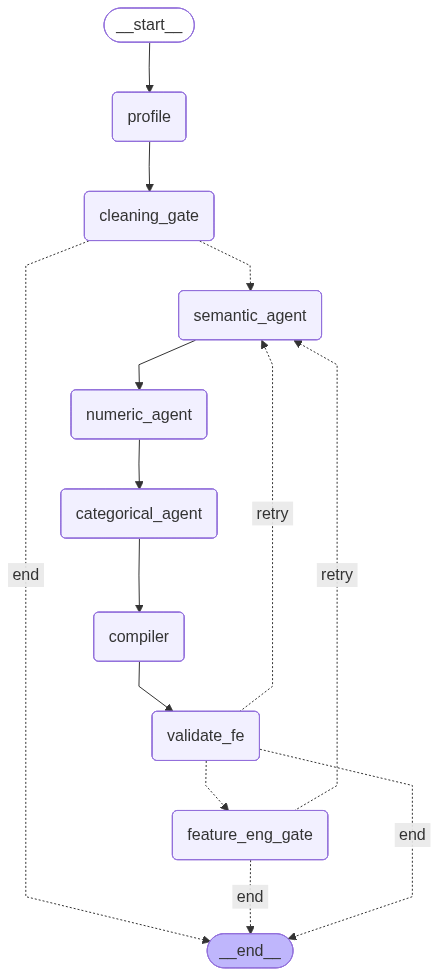

In [48]:
from IPython.display import Image, display
display(Image(pipeline.get_graph().draw_mermaid_png()))

## feature engineering data profile to be read by modelling agent

In [49]:
final_state['feature_stats_report']


{'structural_overview': {'total_rows': 5270673,
  'total_columns': 61,
  'column_types': {'Start_Time_Month': 'IntegerType()',
   'Severity': 'IntegerType()',
   'Start_Lat': 'DoubleType()',
   'Start_Lng': 'DoubleType()',
   'Distance(mi)': 'DoubleType()',
   'Humidity(%)': 'DoubleType()',
   'Pressure(in)': 'DoubleType()',
   'Wind_Speed(mph)': 'DoubleType()',
   'Precipitation(in)': 'DoubleType()',
   'Crossing': 'IntegerType()',
   'Junction': 'IntegerType()',
   'Stop': 'IntegerType()',
   'Traffic_Signal': 'IntegerType()',
   'Start_Time_Year': 'IntegerType()',
   'Start_Time_Day_of_Week': 'IntegerType()',
   'Start_Time_Hour': 'IntegerType()',
   'Start_Time_is_Weekend': 'IntegerType()',
   'End_Time_Year': 'IntegerType()',
   'End_Time_Month': 'IntegerType()',
   'End_Time_Day_of_Week': 'IntegerType()',
   'End_Time_Hour': 'IntegerType()',
   'End_Time_is_Weekend': 'IntegerType()',
   'Duration_Seconds': 'LongType()',
   'is_rush_hour': 'IntegerType()',
   'is_highway': 'Intege

In [50]:
print(f"feature_validation_status: {final_state.get('feature_validation_status')}")
print(f"feature_validation_message: {final_state.get('feature_validation_message')}")
print(f"feature_auto_decision: {final_state.get('feature_auto_decision')}")

feature_validation_status: approved
feature_validation_message: Engineered features accepted for modeling.
feature_auto_decision: {'decision': 'accept', 'status': 'approved', 'validation_passed': True, 'semantic_flags_reviewed': 21, 'suspicious_semantic_flags': [{'target_column': 'is_rural_street', 'reason': 'true_ratio too low (0.0006) -> likely over-specific regex'}, {'target_column': 'is_one_way', 'reason': 'true_ratio too low (0.0000) -> likely over-specific regex'}, {'target_column': 'is_residential_area', 'reason': 'true_ratio too low (0.0001) -> likely over-specific regex'}], 'warning_count': 0, 'quality_issues': [], 'reason': 'Engineered features accepted for modeling.'}


## manually drop suspicious boolean flags
These flags have true ratio that is too low signalling that the flag provides no further predictive value and the eventual model may memorise the few cases and fail to generalise well.

In [51]:
gate_decision = final_state.get('feature_auto_decision')
sus_flags = gate_decision.get('suspicious_semantic_flags', [])
sus_cols_to_drop = [flag['target_column'] for flag in sus_flags]
print(sus_cols_to_drop)

['is_rural_street', 'is_one_way', 'is_residential_area']


In [53]:
feature_df = feature_df.drop(*sus_cols_to_drop)
feature_df.cache()
feature_df.count()
feature_df.write.mode("overwrite").parquet("data/engineered_df.parquet")
feature_df.unpersist()
print("Succesfully dropped suspicious columns with severely low true ratios")


26/04/13 01:38:51 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB
26/04/13 01:39:27 WARN DAGScheduler: Broadcasting large task binary with size 8.1 MiB
26/04/13 01:39:28 WARN DAGScheduler: Broadcasting large task binary with size 16.3 MiB


Succesfully dropped suspicious columns with severely low true ratios


In [54]:
feature_df.show(5)

26/04/13 01:40:12 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB


+----------------+--------+------------------+------------------+------------------+-----------+------------+---------------+-----------------+--------+--------+----+--------------+---------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+------------+----------+---------------+--------------+-------------+---------------+-------------+----------------+-------+-------+------+--------+--------+-----------+---------------+-----------------+-----------------+-------------------+-------+------------------------------------------+-----------------------------------+-----------------------------------+------------------+------------------+----------------+--------+----------+-----------+--------------+-------------+------------------+------------------+------------------+---------------------+-------------------------+
|Start_Time_Month|Severity|         Start_Lat|         